In [1]:
import time
notebook_start = time.perf_counter()

import  os, json, joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    matplotlib.ticker import AutoMinorLocator
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.ensemble import RandomForestRegressor
from    sklearn.metrics import mean_squared_error
from    sklearn.model_selection import learning_curve

OUTPUT_FOLDER = "RF_Pdew_OUTPUTS"
TEST_ROWS     = None
N_JOBS        = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
print(f"RF parallel jobs: {N_JOBS}")


RF parallel jobs: 24


In [2]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\nP_dew statistics:")
print(df["P_dew"].describe())

Total samples: 19361

P_dew statistics:
count    19361.000000
mean        23.025120
std         18.245683
min          2.623504
25%          6.876419
50%         16.994768
75%         35.466456
max         78.580621
Name: P_dew, dtype: float64


In [3]:
target     = "P_dew"
SEED       = 8005515
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


In [4]:
# plot_correlation_heatmap(df, features, target, save_path="RF_P_dew_correlation", folder=OUTPUT_FOLDER)

In [5]:
# Train Random Forest model

Trees = 200

rf_model = RandomForestRegressor(
    n_estimators=Trees,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEED,
    oob_score=True,
    n_jobs=N_JOBS
)

rf_model.fit(X_train, y_train)
print(f"OOB R² Score: {rf_model.oob_score_:.6f}")

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)
y_val_pred   = rf_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

OOB R² Score: 0.999987
Model Performance for P_dew

Training Set:
  R²:   0.999998
  RMSE: 0.024935 bar
  MAE:  0.002013 bar

Test Set:
  R²:   0.999993
  RMSE: 0.047525 bar
  MAE:  0.004663 bar

Validation Set:
  R²:   0.999994
  RMSE: 0.044198 bar
  MAE:  0.004224 bar


In [6]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: RF_Pdew_OUTPUTS/RF_P_dew_model.joblib


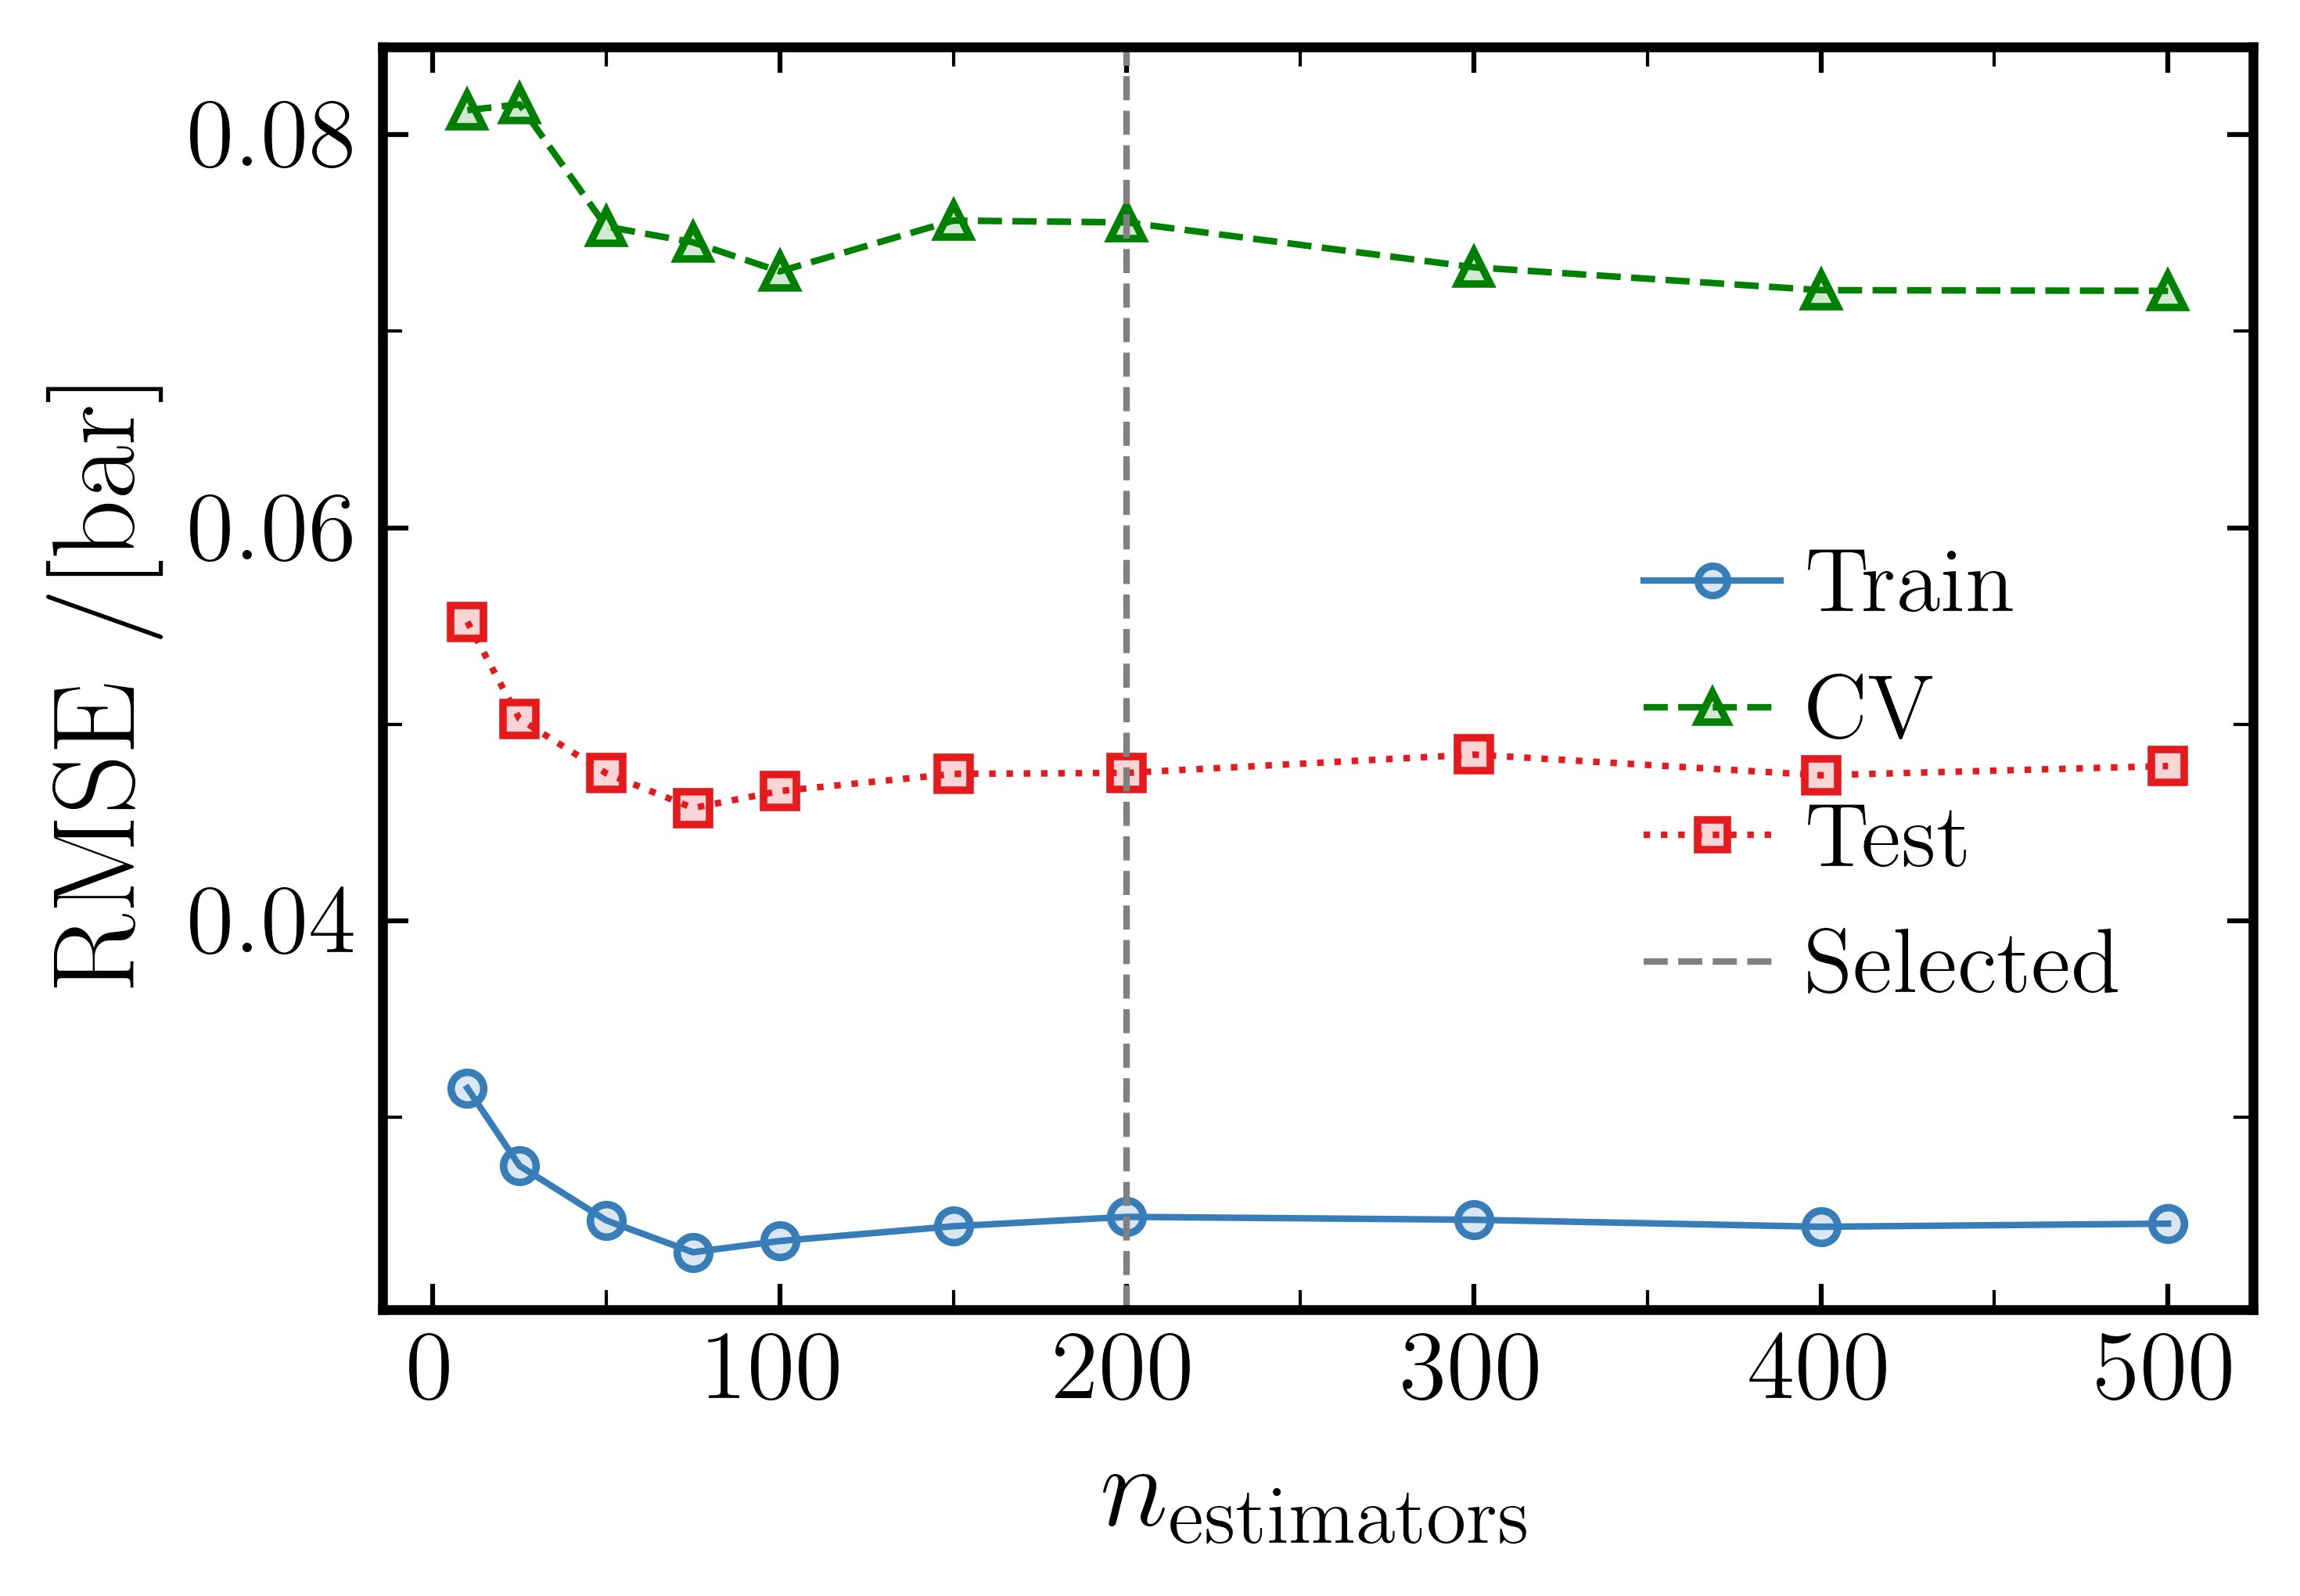

Saved: RF_P_dew_nestimators_convergence


In [20]:
# n_estimators convergence: RMSE vs number of trees
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.
checkpoints = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
train_rmse_conv = []
cv_rmse_conv    = []
test_rmse_conv  = []

for n in checkpoints:
    _conv_model = RandomForestRegressor(
        n_estimators=n, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
    )
    _conv_model.fit(X_train, y_train)
    train_rmse_conv.append(np.sqrt(mean_squared_error(y_train, _conv_model.predict(X_train))))
    test_rmse_conv.append( np.sqrt(mean_squared_error(y_test,  _conv_model.predict(X_test))))
    cv_rmse_conv.append(
        -cross_val_score(
            _conv_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

_lfs = ps.label_fontsize + 4
_tls = ps.tick_labelsize + 5
_mfc = lambda c: (*ps.mcolors.to_rgb(c), 0.18)

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(checkpoints, train_rmse_conv,
        marker='o', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[2], markerfacecolor=_mfc(ps.colors[2]),
        markeredgecolor=ps.colors[2], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Train}$')
ax.plot(checkpoints, cv_rmse_conv,
        marker='^', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[1], markerfacecolor=_mfc(ps.colors[1]),
        markeredgecolor=ps.colors[1], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{CV}$')
ax.plot(checkpoints, test_rmse_conv,
        marker='s', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[0], markerfacecolor=_mfc(ps.colors[0]),
        markeredgecolor=ps.colors[0], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Test}$')
ax.axvline(Trees, ls='--', color='gray', lw=ps.linewidth, label=r'$\mathrm{Selected}$')
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=_lfs)
ax.set_ylabel(r"$\mathrm{RMSE}\ / [\mathrm{bar}]$", fontsize=_lfs)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x)}$"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:g}$"))
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='major', labelsize=_tls)
ax.tick_params(axis='both', which='minor', length=3)
leg = ps.style_legend(ax, loc=(0.65,0.2), fontsize=ps.label_fontsize)
leg.get_frame().set_visible(False)
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_nestimators_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_nestimators_convergence")

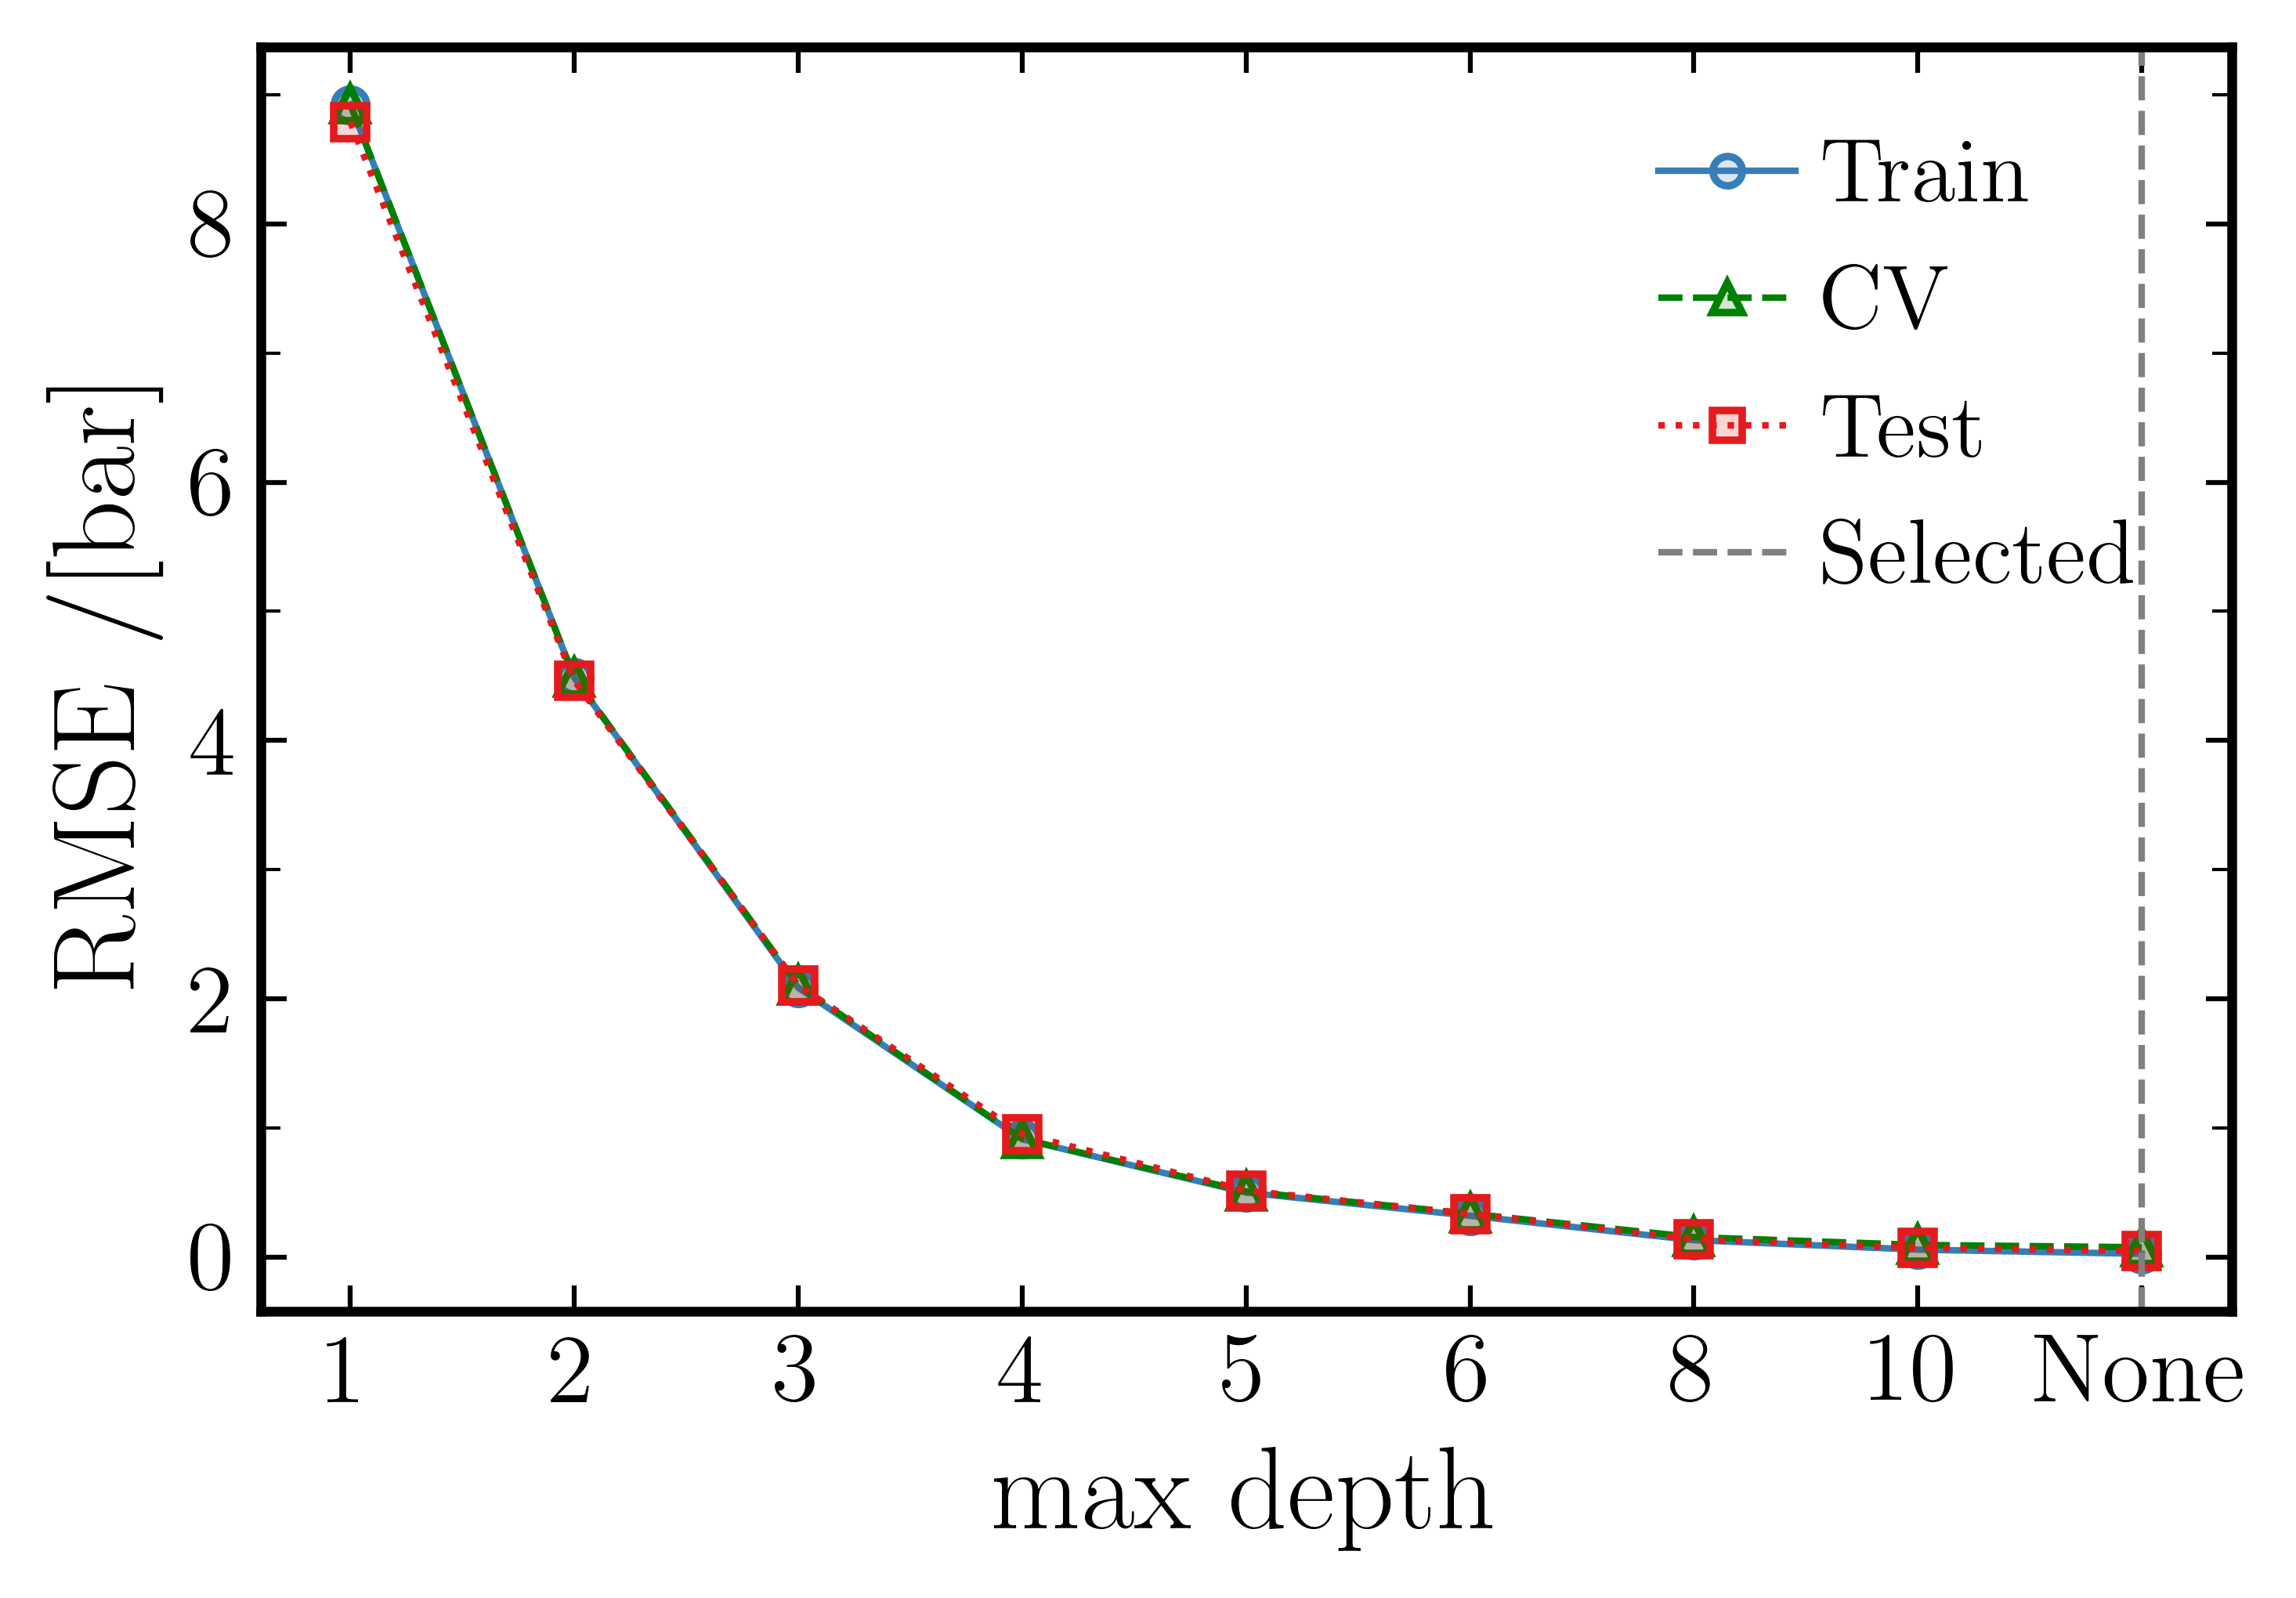

Saved: RF_P_dew_max_depth_convergence


In [21]:
# max_depth convergence: RMSE vs tree depth
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.

depth_checkpoints = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_rmse_depth = []
cv_rmse_depth    = []
test_rmse_depth  = []

for depth in depth_checkpoints:
    _depth_model = RandomForestRegressor(
        n_estimators=Trees,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=N_JOBS,
    )
    _depth_model.fit(X_train, y_train)
    train_rmse_depth.append(np.sqrt(mean_squared_error(y_train, _depth_model.predict(X_train))))
    test_rmse_depth.append( np.sqrt(mean_squared_error(y_test,  _depth_model.predict(X_test))))
    cv_rmse_depth.append(
        -cross_val_score(
            _depth_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

depth_labels = ["None" if depth is None else str(depth) for depth in depth_checkpoints]
x_depth = np.arange(len(depth_labels))

_lfs = ps.label_fontsize + 4
_tls = ps.tick_labelsize + 5
_mfc = lambda c: (*ps.mcolors.to_rgb(c), 0.18)

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(x_depth, train_rmse_depth,
        marker='o', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[2], markerfacecolor=_mfc(ps.colors[2]),
        markeredgecolor=ps.colors[2], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Train}$')
ax.plot(x_depth, cv_rmse_depth,
        marker='^', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[1], markerfacecolor=_mfc(ps.colors[1]),
        markeredgecolor=ps.colors[1], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{CV}$')
ax.plot(x_depth, test_rmse_depth,
        marker='s', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[0], markerfacecolor=_mfc(ps.colors[0]),
        markeredgecolor=ps.colors[0], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Test}$')

selected_depth = "None" if rf_model.max_depth is None else str(rf_model.max_depth)
if selected_depth in depth_labels:
    ax.axvline(depth_labels.index(selected_depth), ls='--', color='gray', lw=ps.linewidth,
               label=r'$\mathrm{Selected}$')

ax.set_xticks(x_depth)
ax.set_xticklabels(
    [r"$\mathrm{None}$" if l == "None" else f"${l}$" for l in depth_labels],
    fontsize=_tls,
)
ax.set_xlabel(r"$\mathrm{max\ depth}$", fontsize=_lfs)
ax.set_ylabel(r"$\mathrm{RMSE}\ / [\mathrm{bar}]$", fontsize=_lfs)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:g}$"))
# ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='major', labelsize=_tls)
ax.tick_params(axis='both', which='minor', length=3)
leg = ps.style_legend(ax, loc='upper right', fontsize=ps.label_fontsize)
leg.get_frame().set_visible(False)
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_max_depth_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_max_depth_convergence")

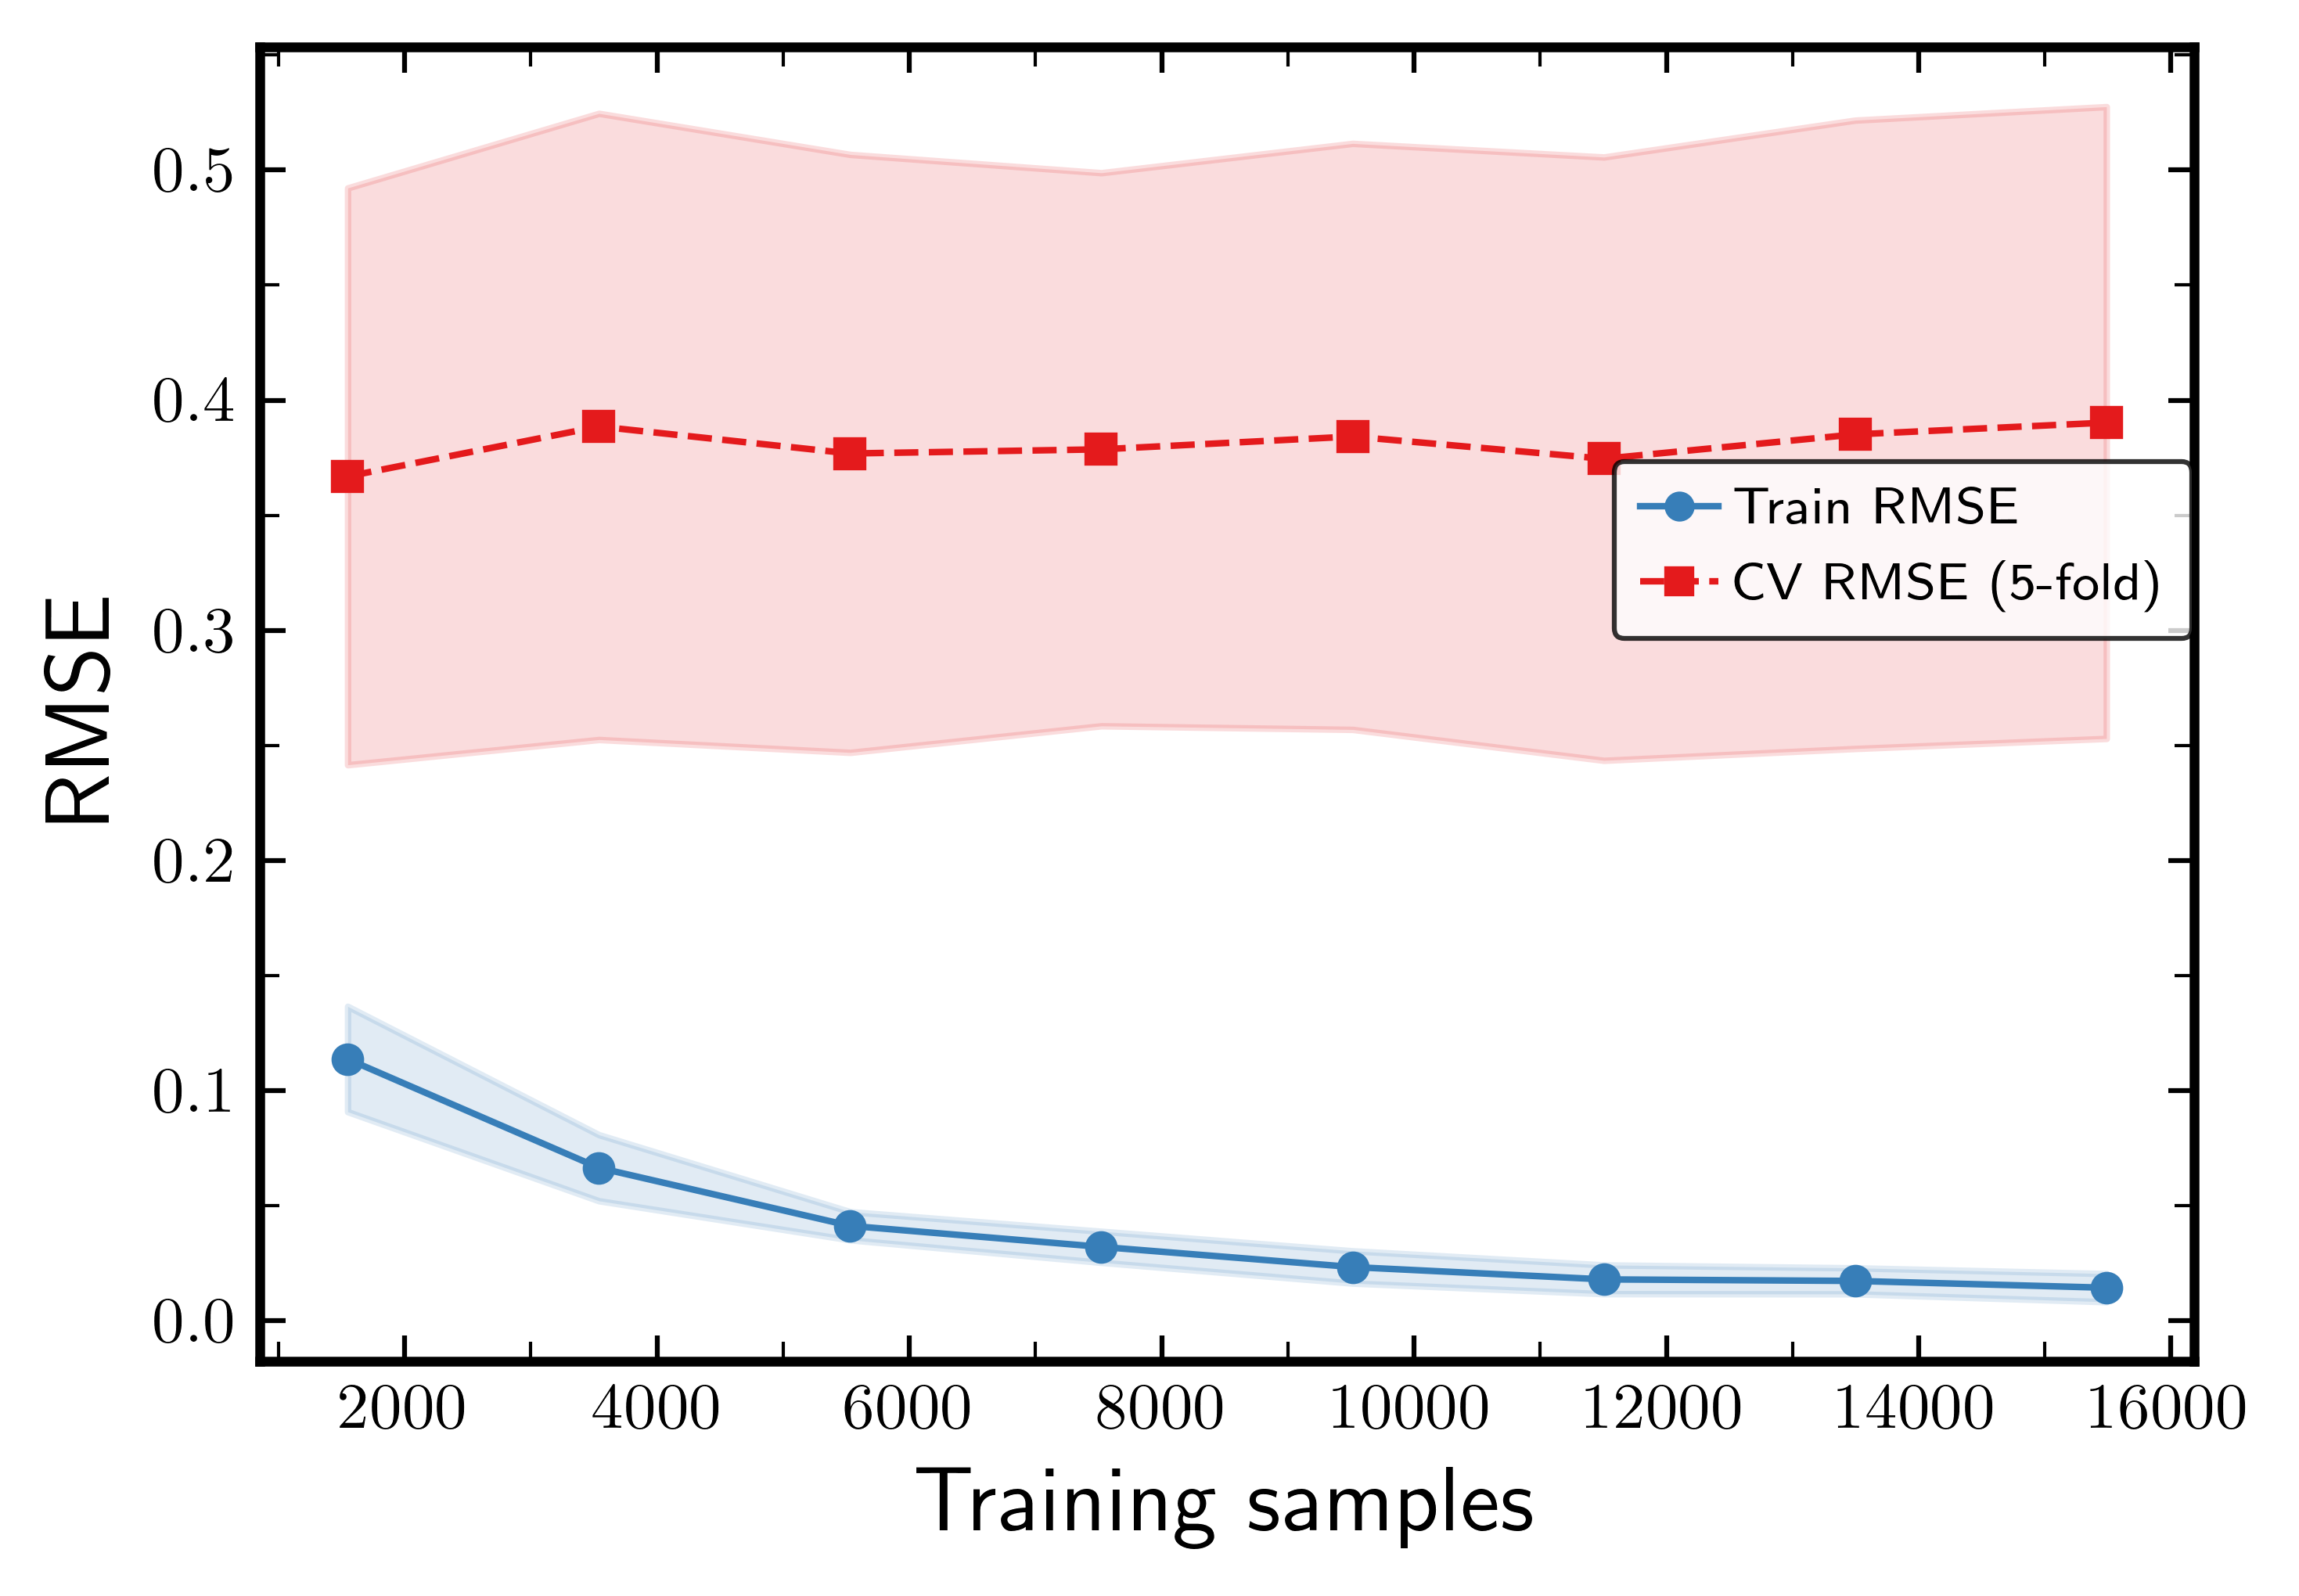

Saved: RF_P_dew_learning_curve


In [9]:
# Learning curve — evaluates whether more data would improve the model
# Uses n_estimators=100 for speed; 5-fold CV across 8 training-set fractions

lc_estimator = RandomForestRegressor(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
)

train_sizes, train_scores, val_scores = learning_curve(
    lc_estimator, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error',
    n_jobs=N_JOBS, shuffle=True, random_state=SEED
)

train_rmse_lc = -train_scores.mean(axis=1)
val_rmse_lc   = -val_scores.mean(axis=1)
train_std_lc  =  train_scores.std(axis=1)
val_std_lc    =  val_scores.std(axis=1)

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(train_sizes, train_rmse_lc, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train RMSE')
ax.fill_between(train_sizes, train_rmse_lc - train_std_lc, train_rmse_lc + train_std_lc,
                color=ps.colors[2], alpha=0.15)
ax.plot(train_sizes, val_rmse_lc,   marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='CV RMSE (5-fold)')
ax.fill_between(train_sizes, val_rmse_lc - val_std_lc, val_rmse_lc + val_std_lc,
                color=ps.colors[0], alpha=0.15)
ax.set_xlabel(r"Training samples", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc=(0.7,0.55))
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_learning_curve", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_learning_curve")

In [10]:
# Error breakdown by temperature quartile (test set)
test_analysis = pd.DataFrame({
    "temperature":   X_test["temperature"].values,
    "actual":        y_test.values,
    "predicted":     y_test_pred,
})
test_analysis["abs_error"]     = np.abs(test_analysis["actual"] - test_analysis["predicted"])
test_analysis["squared_error"] = (test_analysis["actual"] - test_analysis["predicted"]) ** 2
test_analysis["pct_error"]     = test_analysis["abs_error"] / np.abs(test_analysis["actual"]) * 100
test_analysis["temp_bin"]      = pd.qcut(
    test_analysis["temperature"], q=4,
    labels=["Q1 (coldest)", "Q2", "Q3", "Q4 (hottest)"]
)

bin_stats = test_analysis.groupby("temp_bin", observed=True).agg(
    Count    = ("abs_error",     "count"),
    Temp_min = ("temperature",   "min"),
    Temp_max = ("temperature",   "max"),
    MAE      = ("abs_error",     "mean"),
    RMSE     = ("squared_error", lambda x: np.sqrt(x.mean())),
    MAPE_pct = ("pct_error",     "mean"),
).reset_index()

print(f"Error Breakdown by Temperature Quartile — {target} (Test set)\n")
print(bin_stats.to_string(index=False, float_format="{:.4f}".format))

bin_stats.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_error_by_temp_bin.csv"), index=False)
print(f"\nSaved: RF_{target}_error_by_temp_bin.csv")

Error Breakdown by Temperature Quartile — P_dew (Test set)

    temp_bin  Count  Temp_min  Temp_max    MAE   RMSE  MAPE_pct
Q1 (coldest)    760  200.0000  220.0000 0.0001 0.0003    0.0017
          Q2    736  225.0000  245.0000 0.0003 0.0020    0.0023
          Q3    744  250.0000  270.0000 0.0013 0.0058    0.0049
Q4 (hottest)    664  275.0000  300.0000 0.0185 0.0992    0.0303

Saved: RF_P_dew_error_by_temp_bin.csv


Outlier threshold (3σ): ±0.097993
Test outliers: 29/2904 (1.00%)
Val  outliers: 23/2905  (0.79%)
Saved: RF_P_dew_outliers.csv (52 rows)
  idx split  source_id  temperature  pressure    actual  predicted  residual
12789  test         65        295.0 73.366631 65.450272  67.400718 -1.950446
 4228  test         21        290.0 65.401407 60.080348  59.961234  0.119114
  369  test          1        285.0 51.528218 50.082116  50.238178 -0.156062
 8323  test         42        295.0 68.813191 68.813091  67.881657  0.931434
 4237  test         21        295.0 70.332145 68.356731  67.856884  0.499847
 4229  test         21        290.0 68.061887 60.080348  59.961234  0.119114
 7935  test         40        290.0 63.915367 57.049184  57.182061 -0.132877
15687  test         80        295.0 72.451158 69.397688  69.182103  0.215585
 6589  test         33        295.0 67.411430 64.634457  64.732729 -0.098272
 7931  test         40        290.0 60.863775 57.049184  57.265352 -0.216168
17806  test      

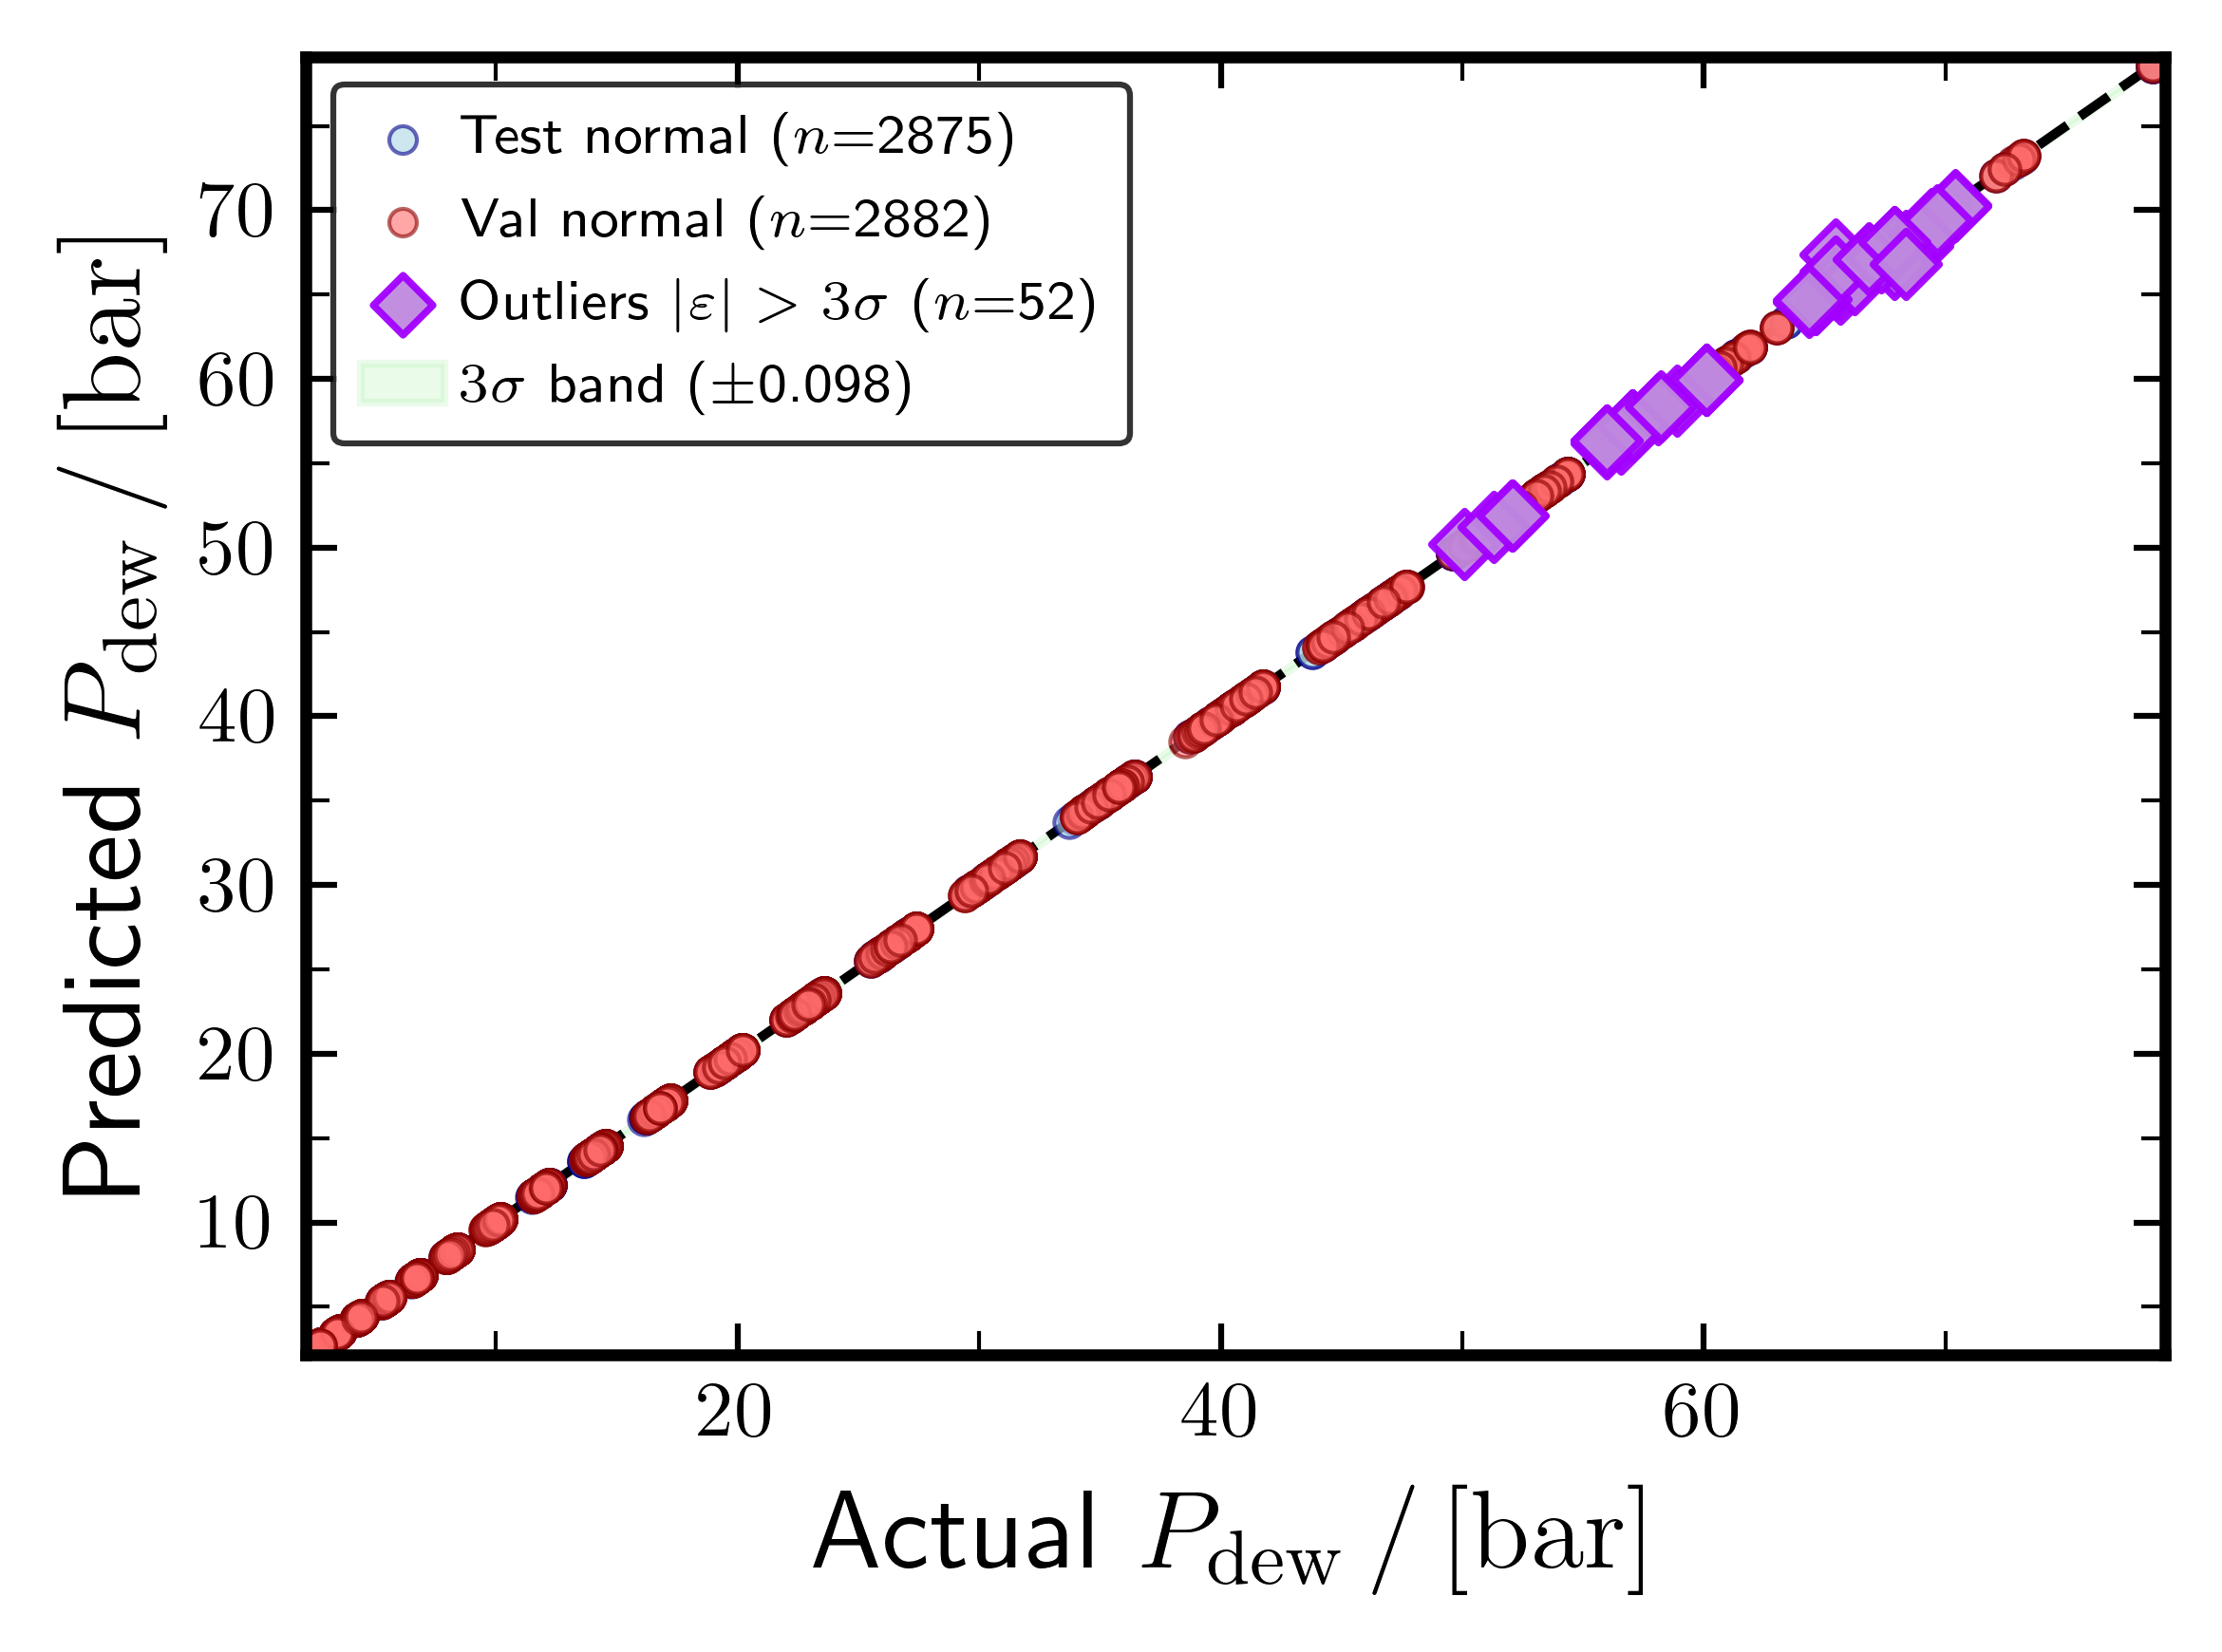

Saved: RF_P_dew_outlier_parity


In [11]:
# Outlier flagging: test + val samples where |residual| > 3 * global std

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3\u03c3): \u00b1{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_outliers.csv"), index=False)
print(f"Saved: RF_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=35, facecolors="#BF89DF", edgecolors="#A200FF",
        linewidths=0.9, marker='D', zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_outlier_parity")

In [12]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=N_JOBS)
cv_rmse_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=N_JOBS)
cv_mae_scores  = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
cv_mape_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=N_JOBS)

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:    {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE:  {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:   {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE:  {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.99959357 0.99961584 0.99873371 0.99961519 0.99984532]
Mean CV R²:    0.999481 (+/- 0.000769)

Cross-Validation RMSE Scores: [0.35979208 0.35705938 0.65147611 0.36210612 0.22860528]
Mean CV RMSE:  0.391808 (+/- 0.278822)

Cross-Validation MAE Scores:  [0.16298595 0.1210847  0.13100315 0.1225062  0.06441054]
Mean CV MAE:   0.120398 (+/- 0.063660)

Cross-Validation MAPE Scores: [0.56660781 0.38352775 0.33436962 0.34630756 0.13278505]
Mean CV MAPE:  0.3527% (+/- 0.2763%)


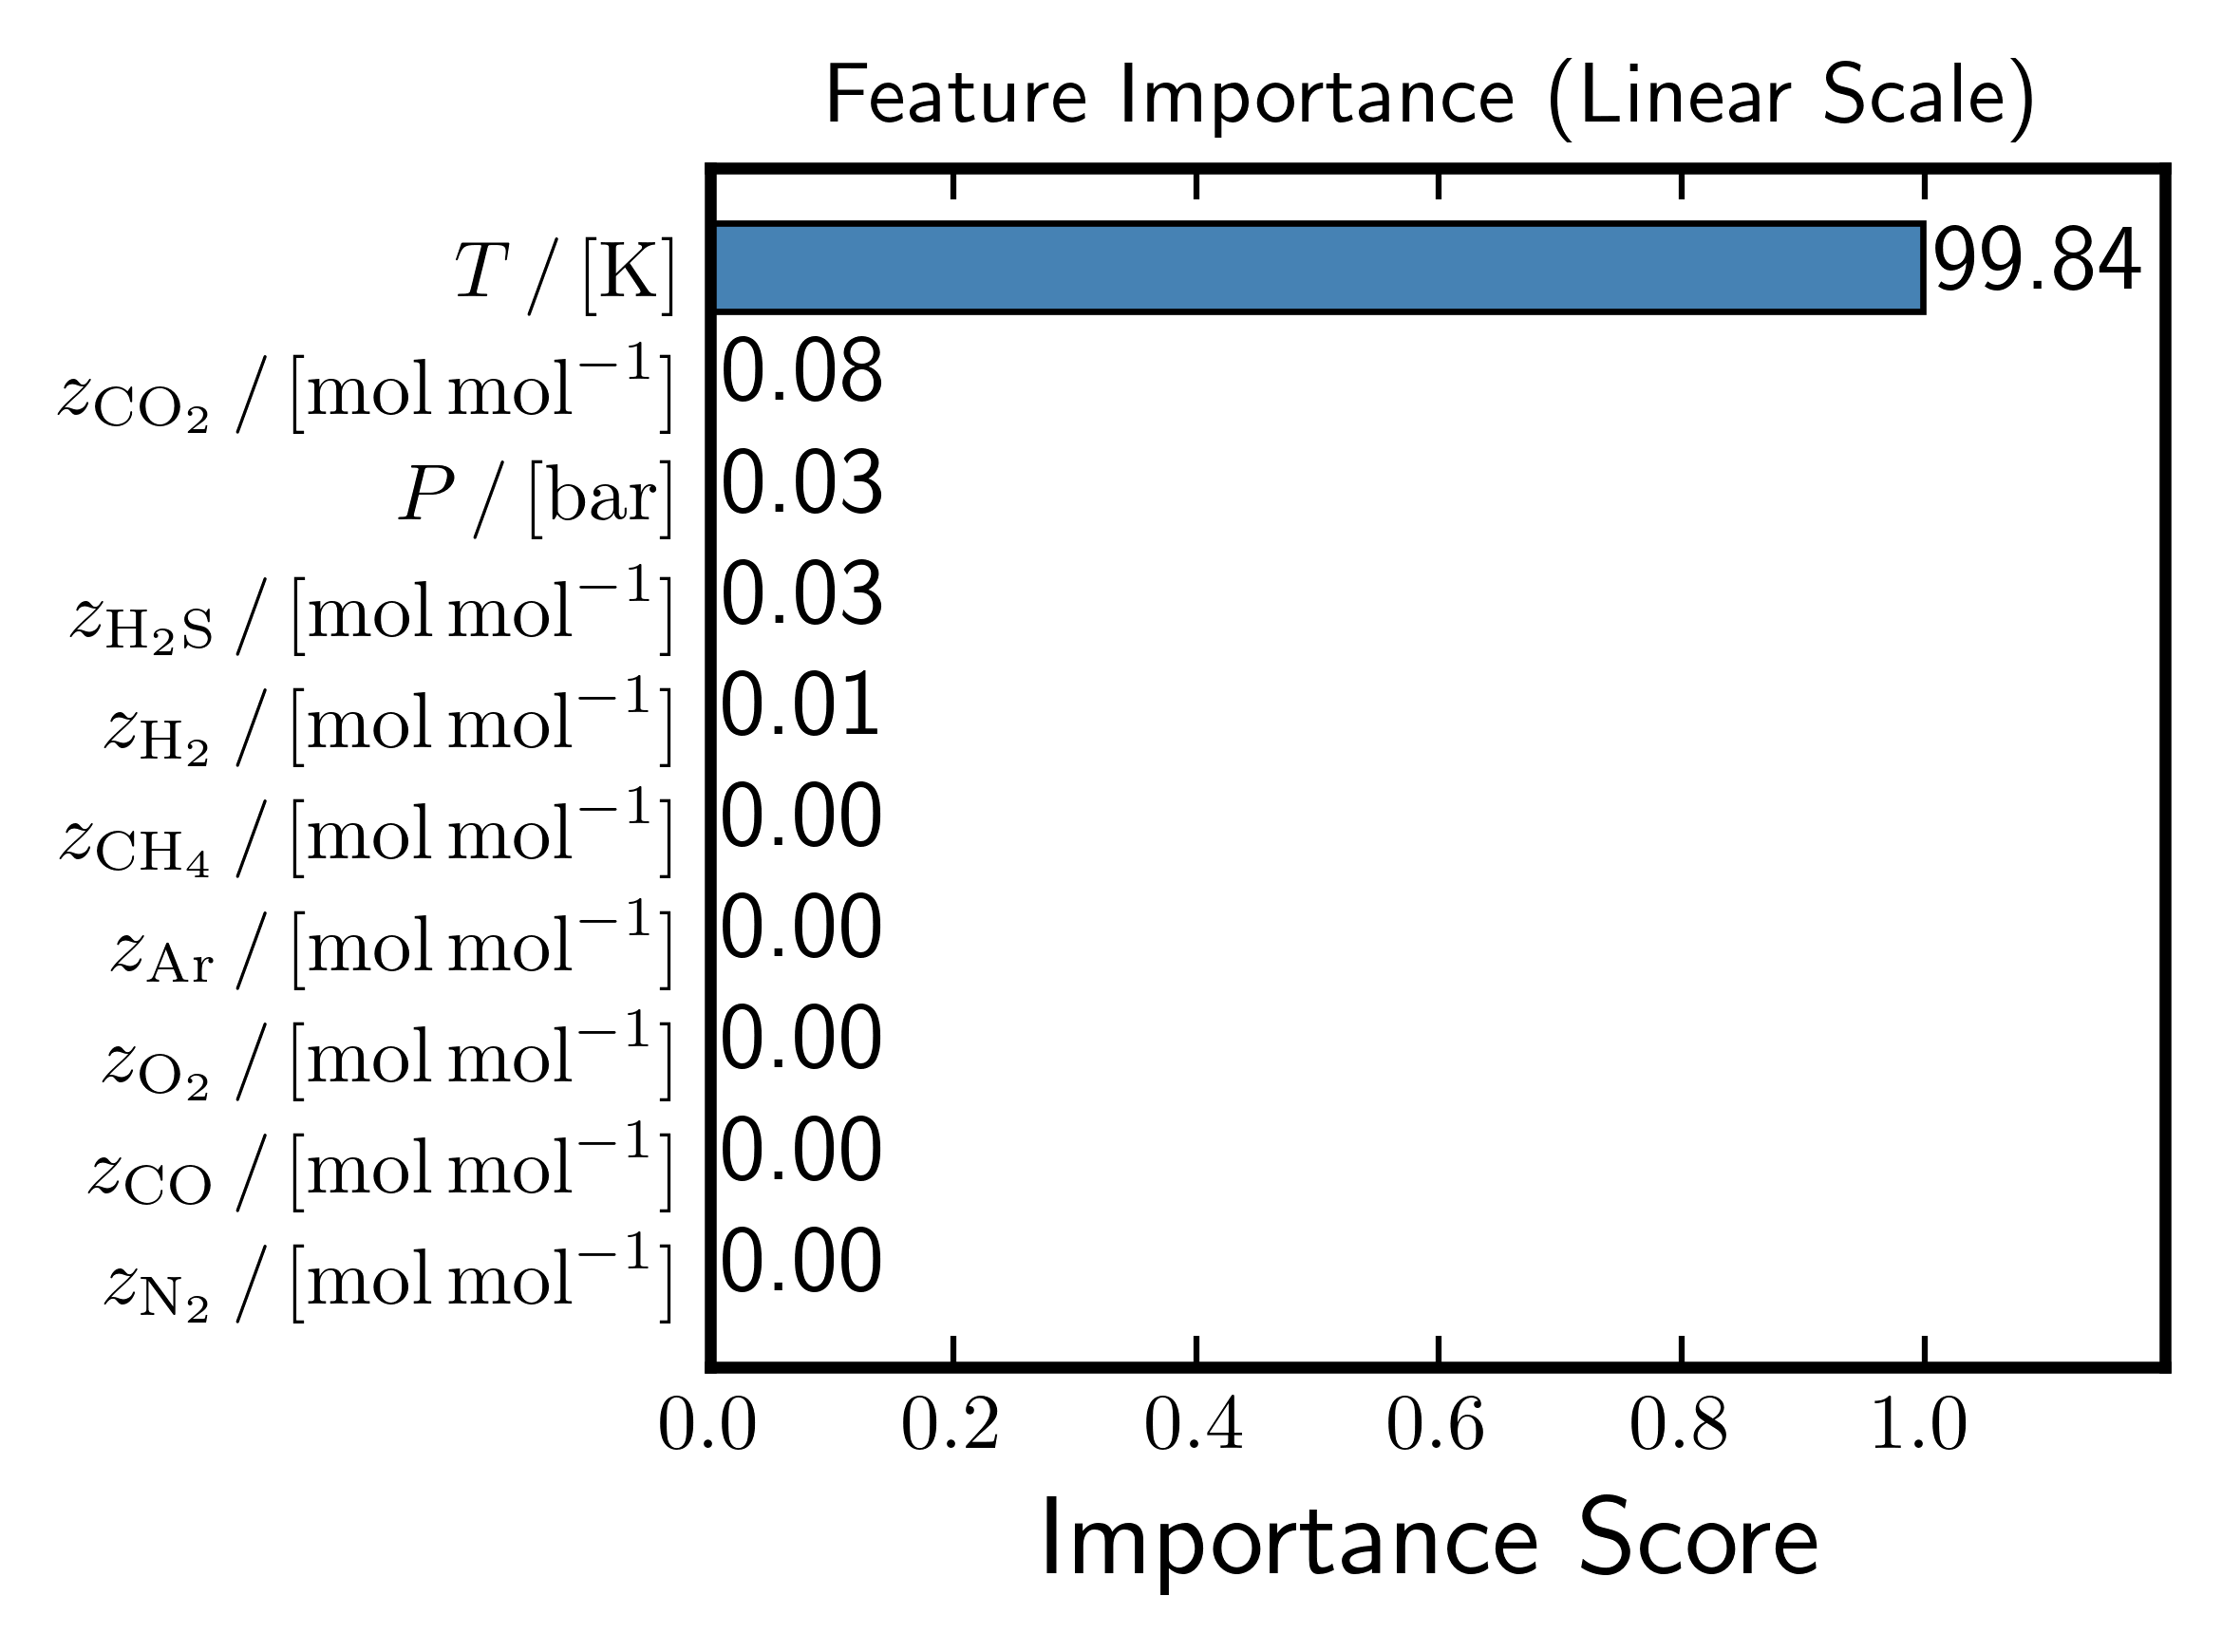

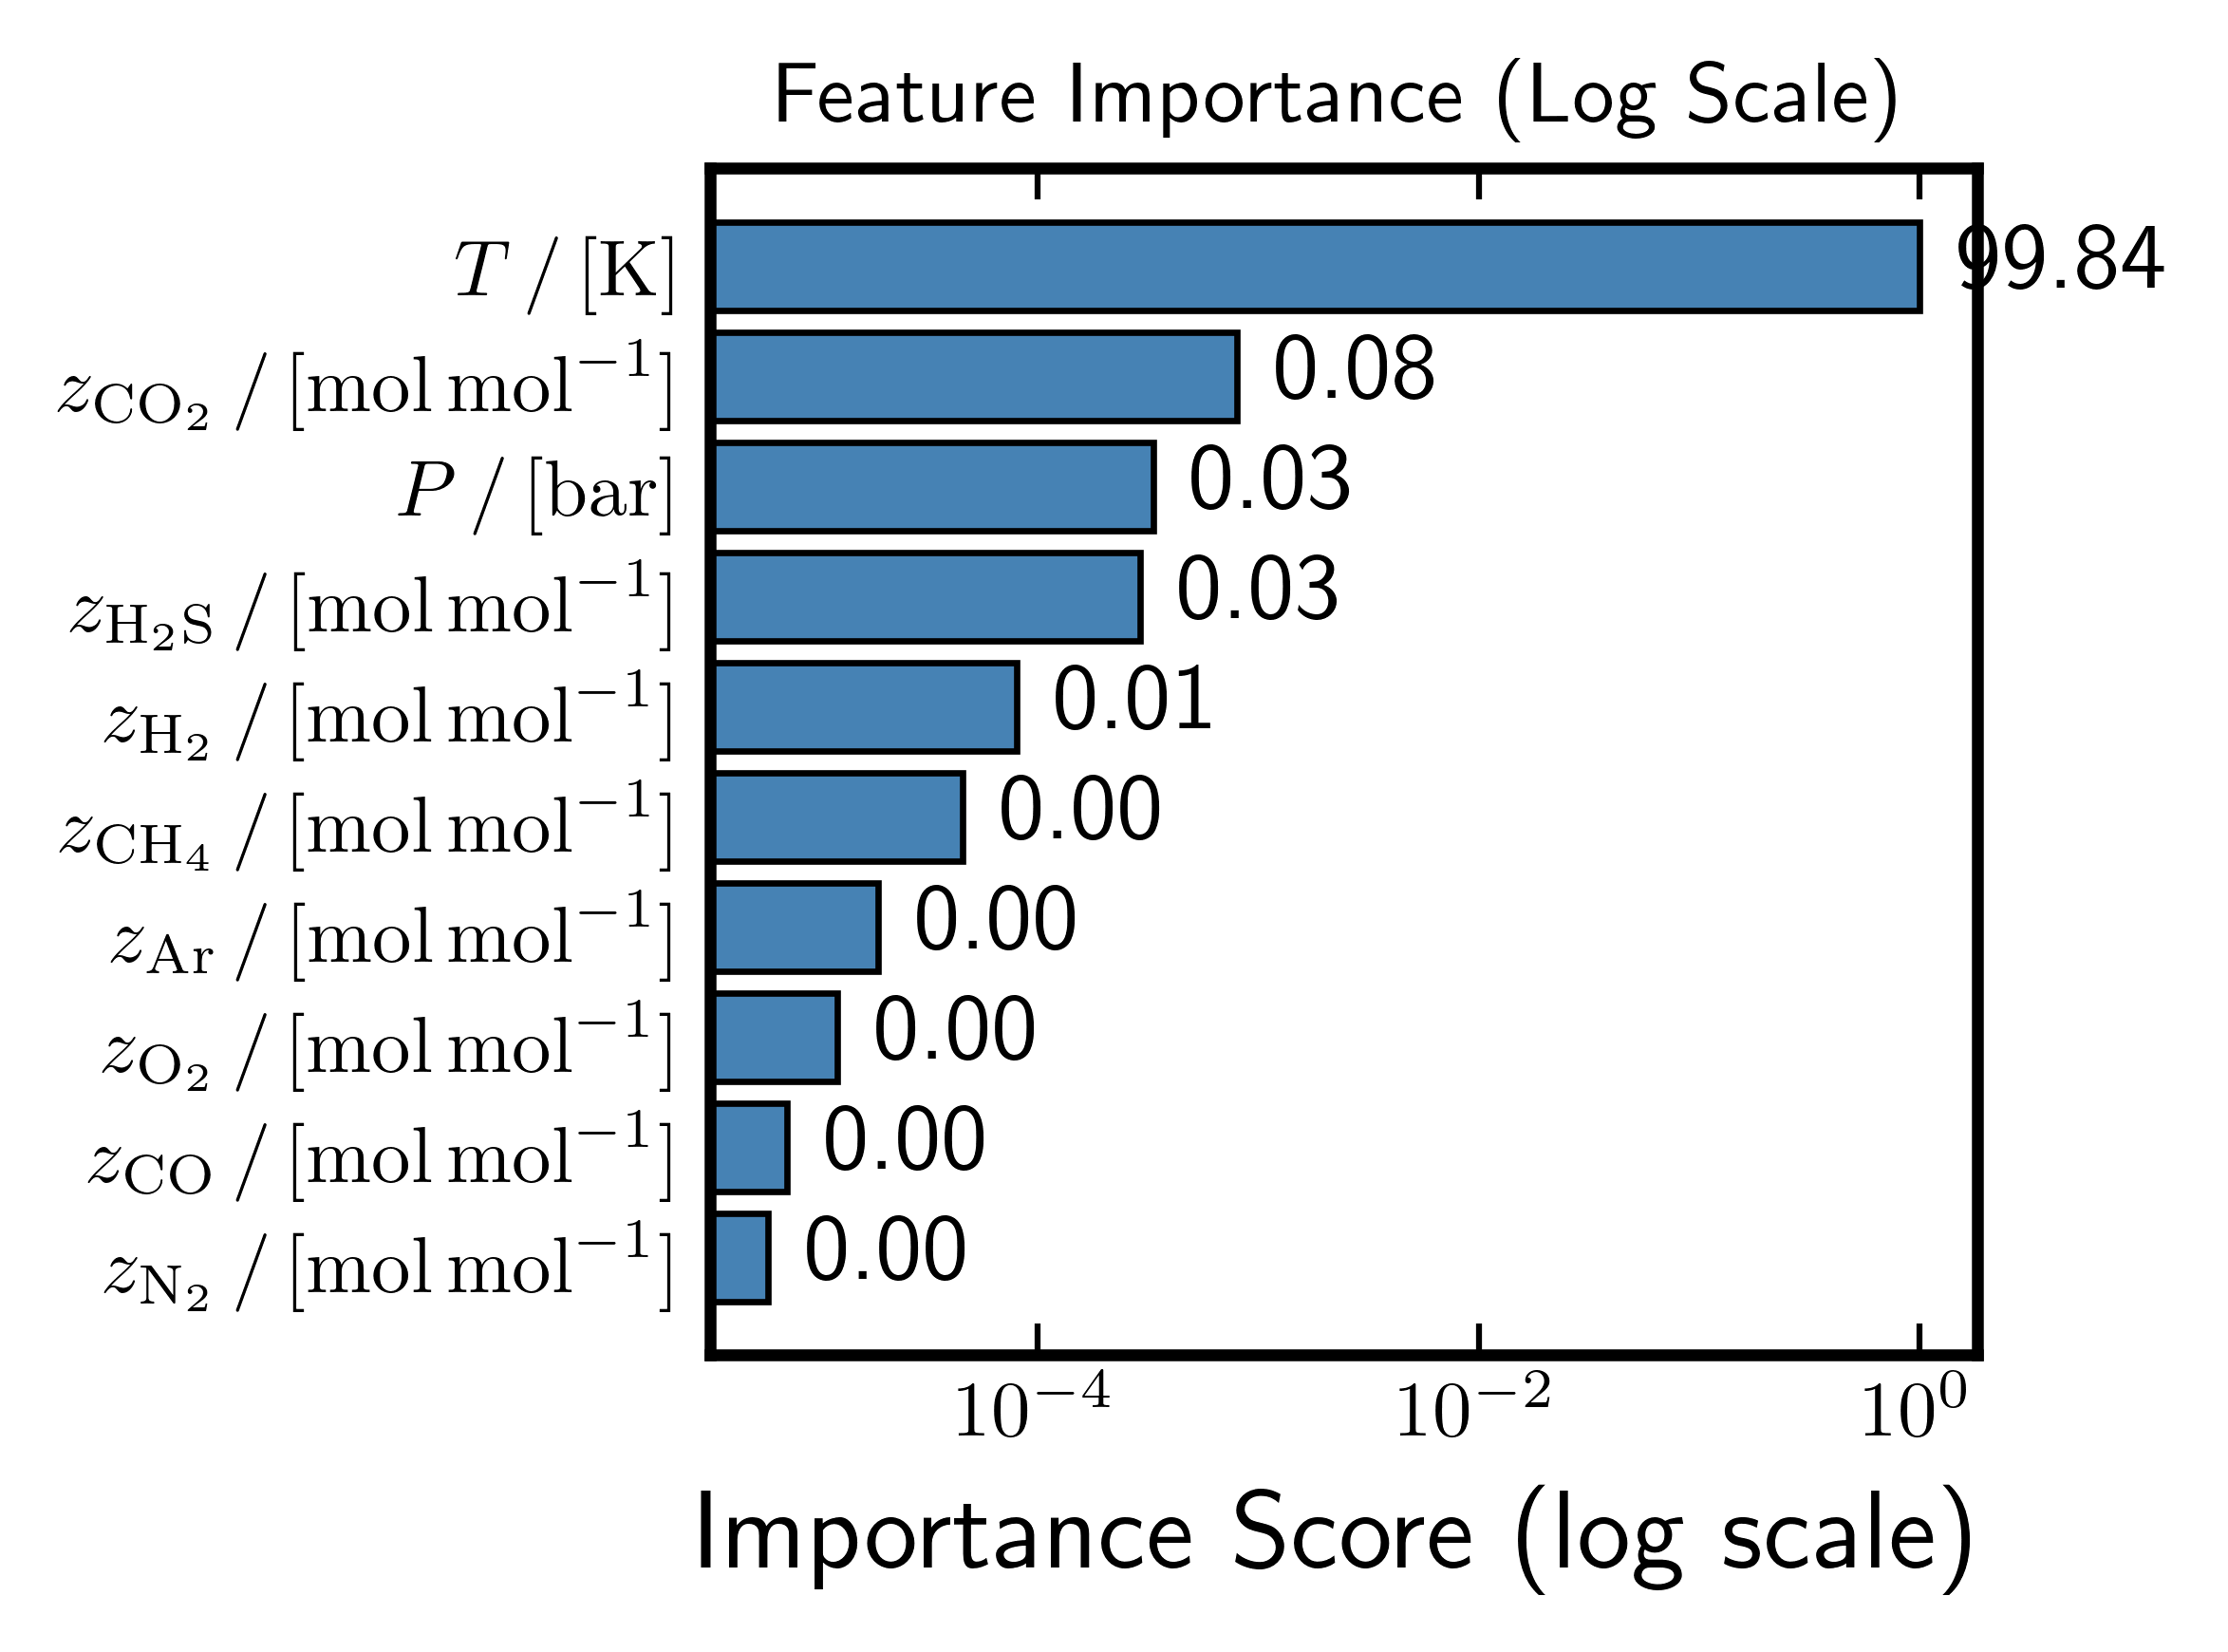

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Log Scale)'}, xlabel='Importance Score (log scale)'>)

In [13]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_dew",
    feature_importances=rf_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="RF_P_dew_feature_importance_linear", folder=OUTPUT_FOLDER)
post.plot_feature_importance(scale="log", color="steelblue", save_path="RF_P_dew_feature_importance_log", folder=OUTPUT_FOLDER)

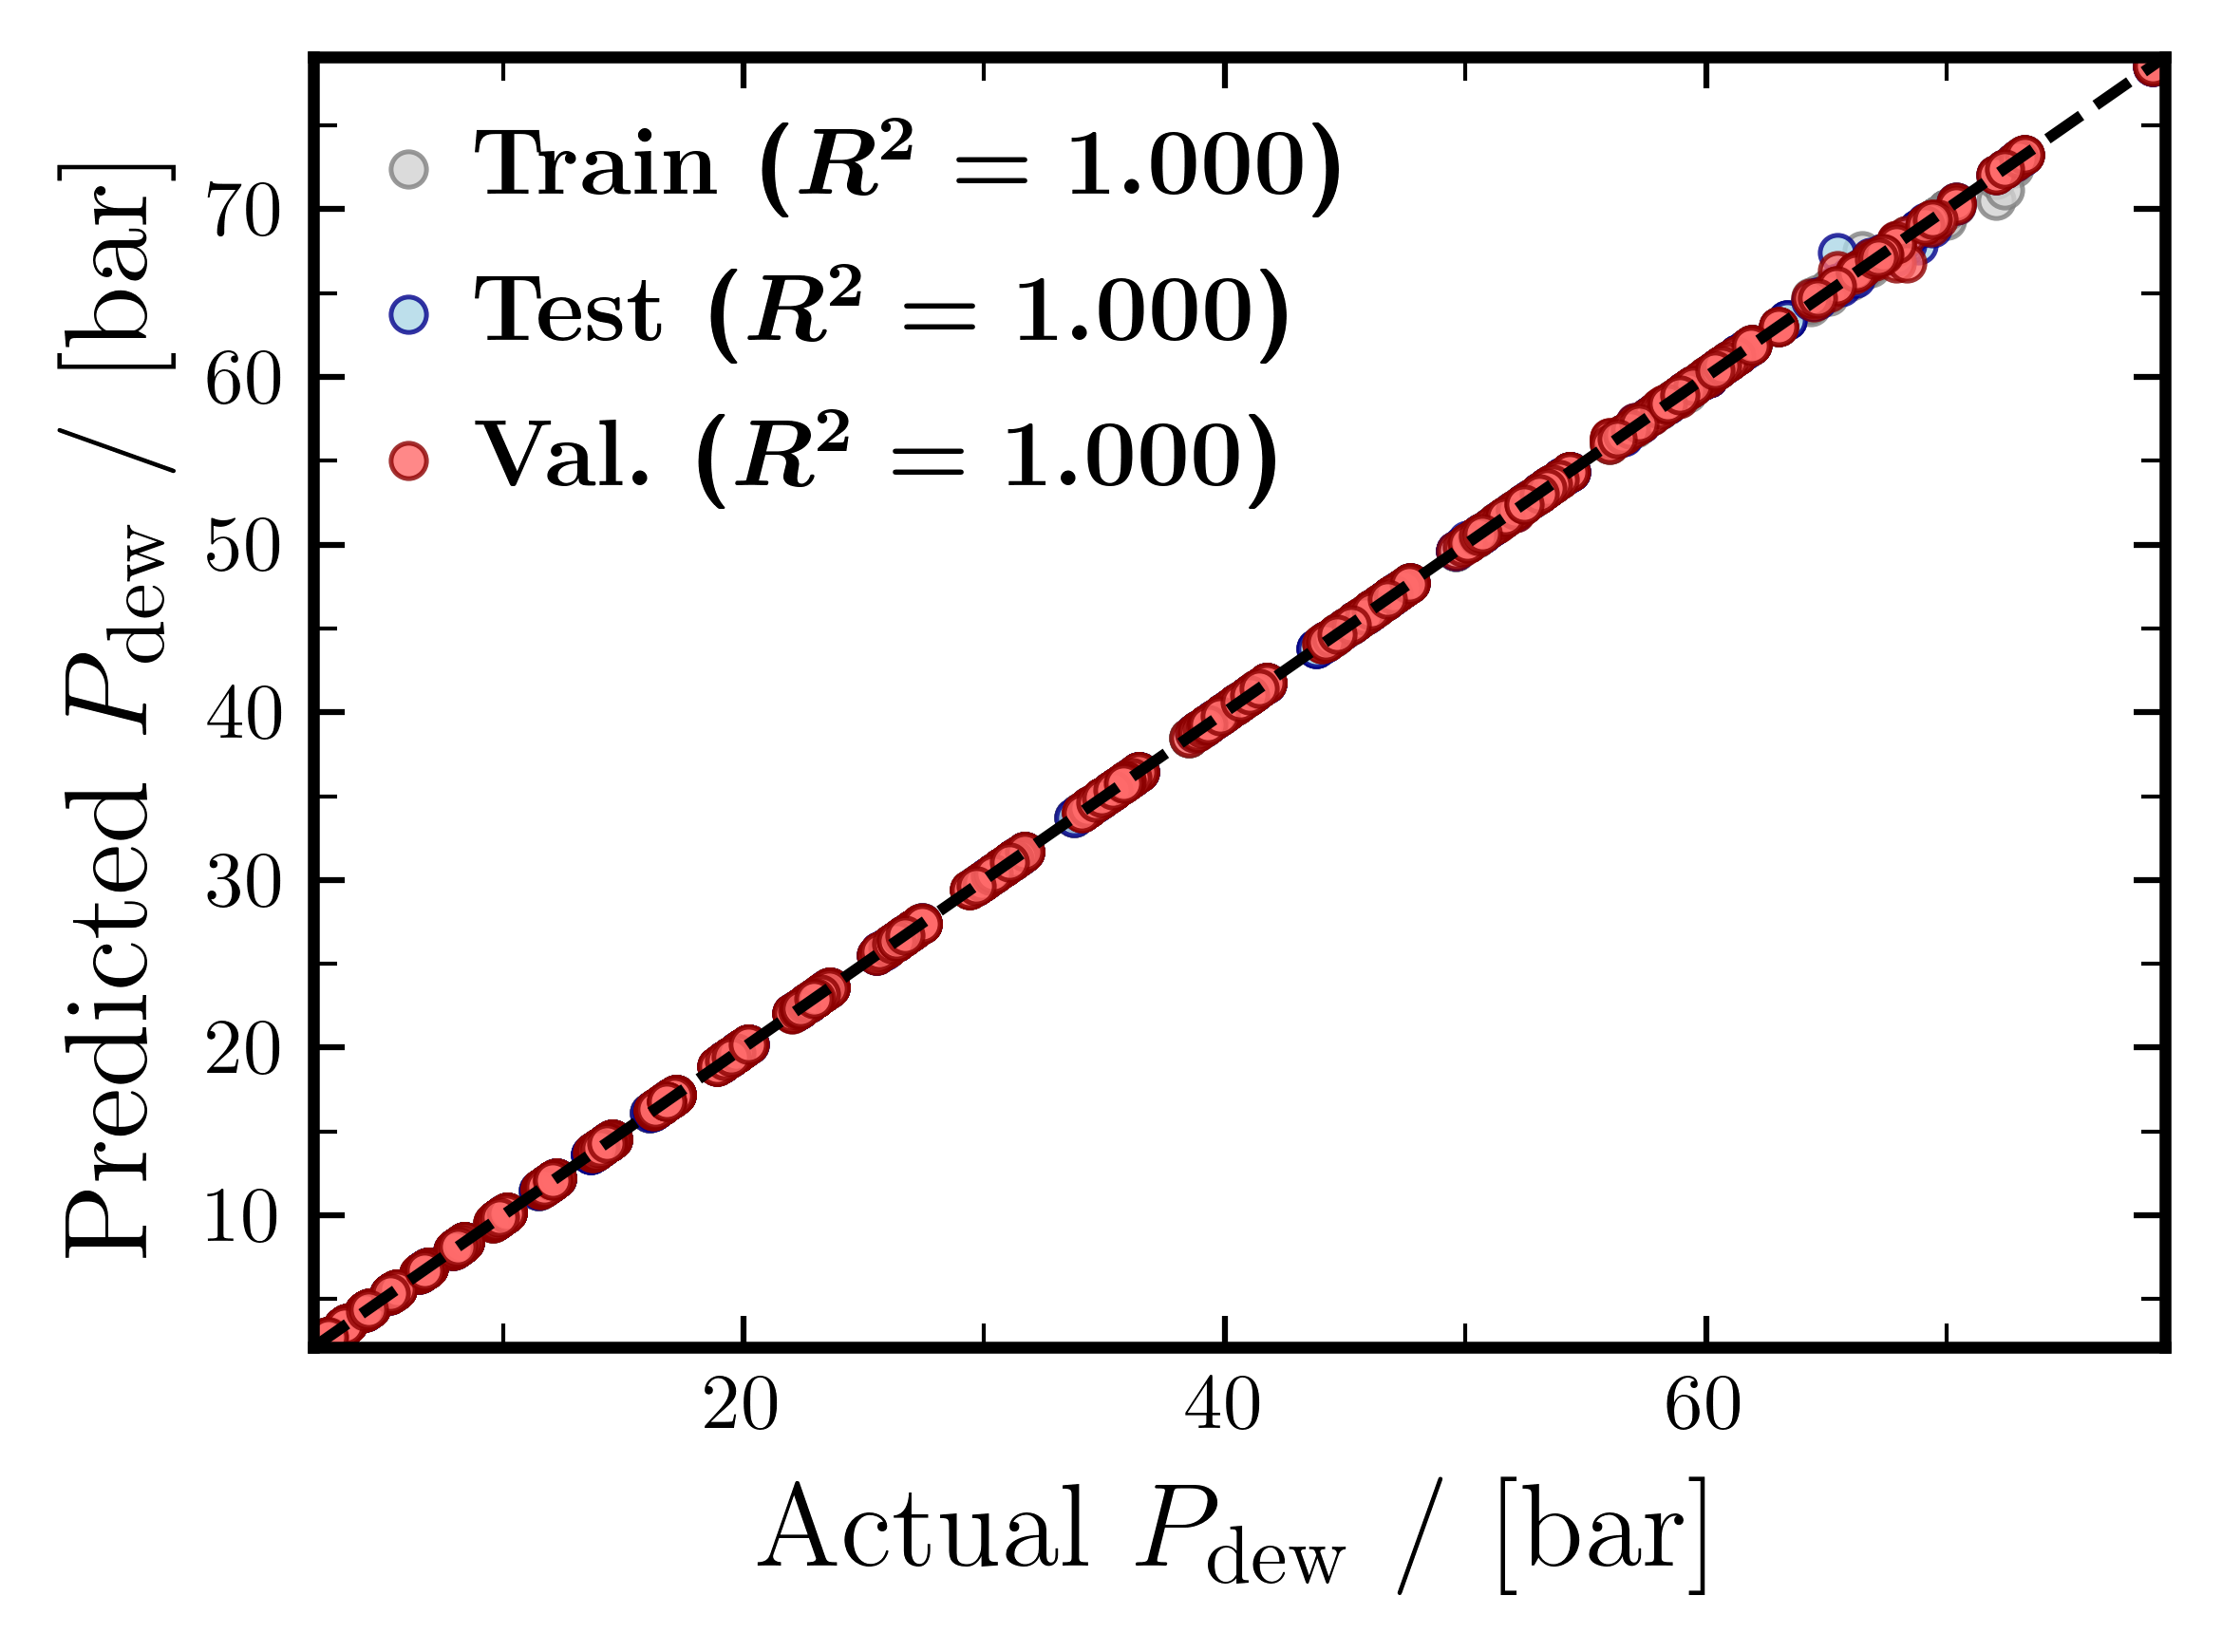

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $P_{\\mathrm{dew}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Predicted}$ $P_{\\mathrm{dew}}$ / $[\\mathrm{bar}]$'>)

In [14]:
# Parity plot
post.plot_parity(
    model_name="Random Forest",
    save_path="RF_P_dew_parity_plot",
    folder=OUTPUT_FOLDER,
    legend_fontsize=12,         # legend text size
    legend_bold=True,           # bold legend labels (math incl. under usetex)
    legend_loc=[0.005,0.62],    # legend location
    legend_handletextpad=0.2,   # gap between marker and text
    legend_handlelength=1.0,    # marker-box width (smaller -> marker closer to text)
    label_fontsize=15,          # x/y axis label size
    labelpad=4,                # gap between axis and its label (points)
    decimals=3,                 # decimal places for R^2 in legend
)

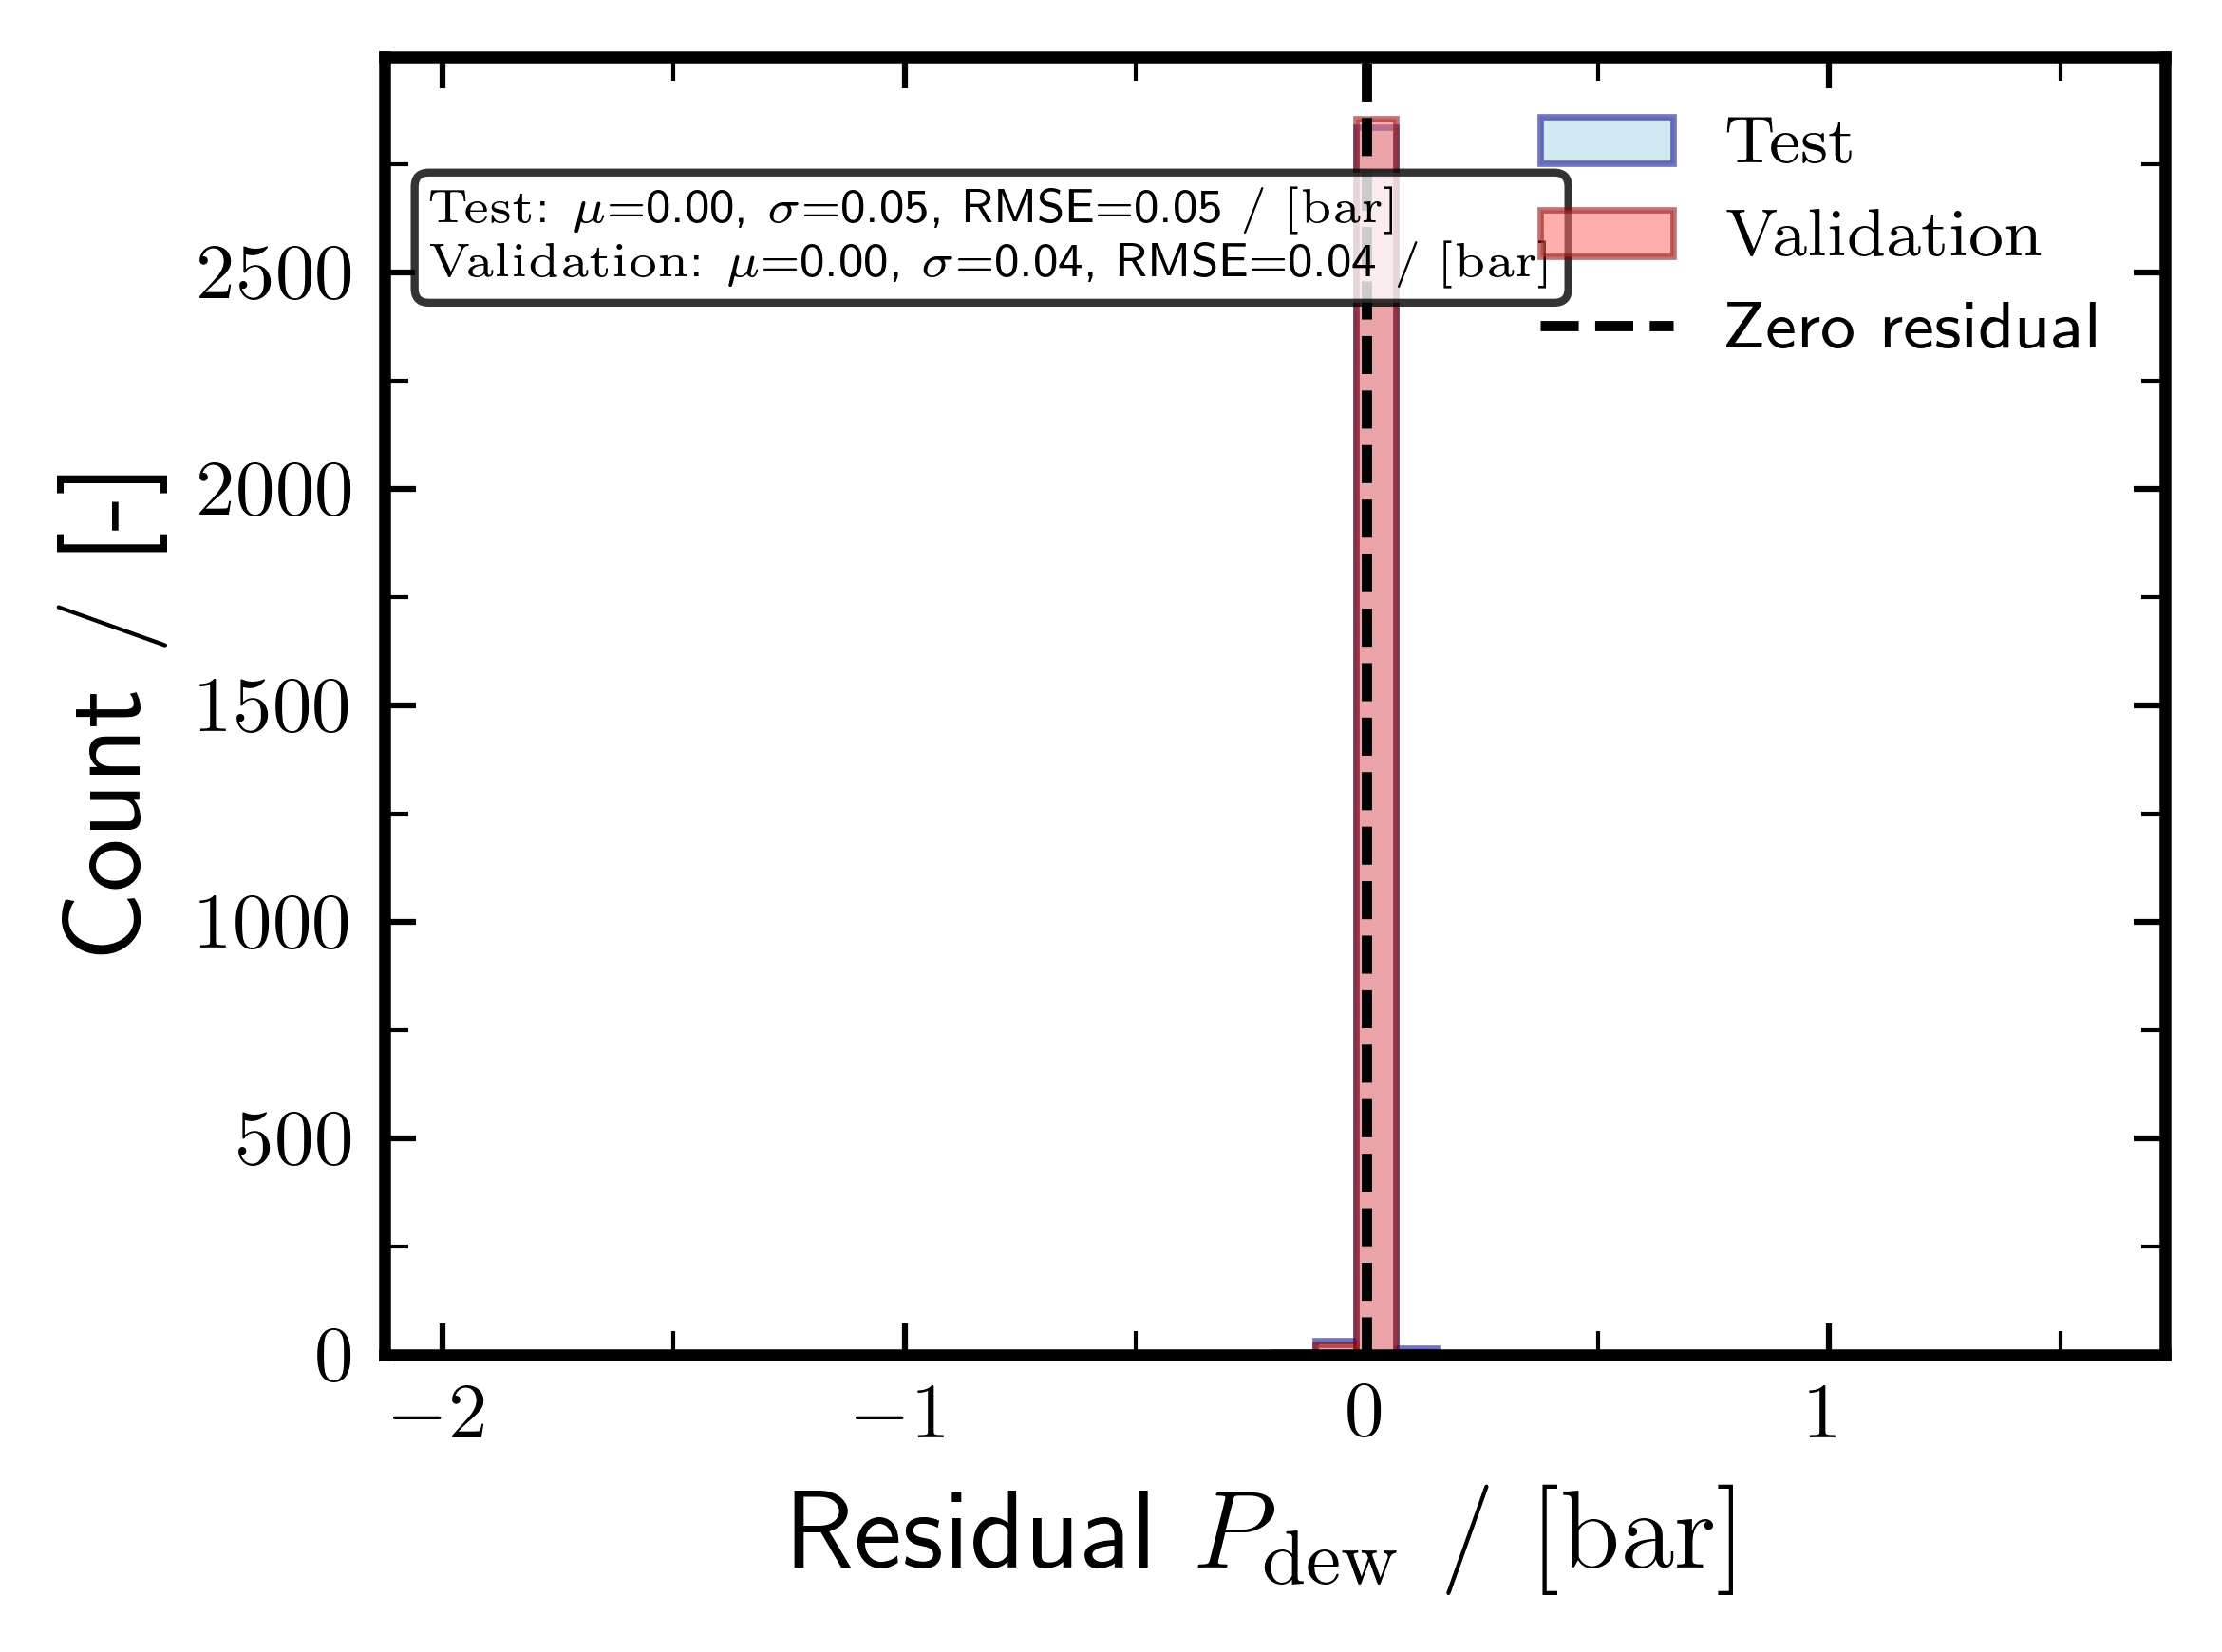

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{dew}}$ / $[\\mathrm{bar}]$', ylabel='Count / [-]'>)

In [15]:
# Residual distribution
post.plot_residual_distribution(save_path="RF_P_dew_residual_distribution", folder=OUTPUT_FOLDER,
    # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
    )

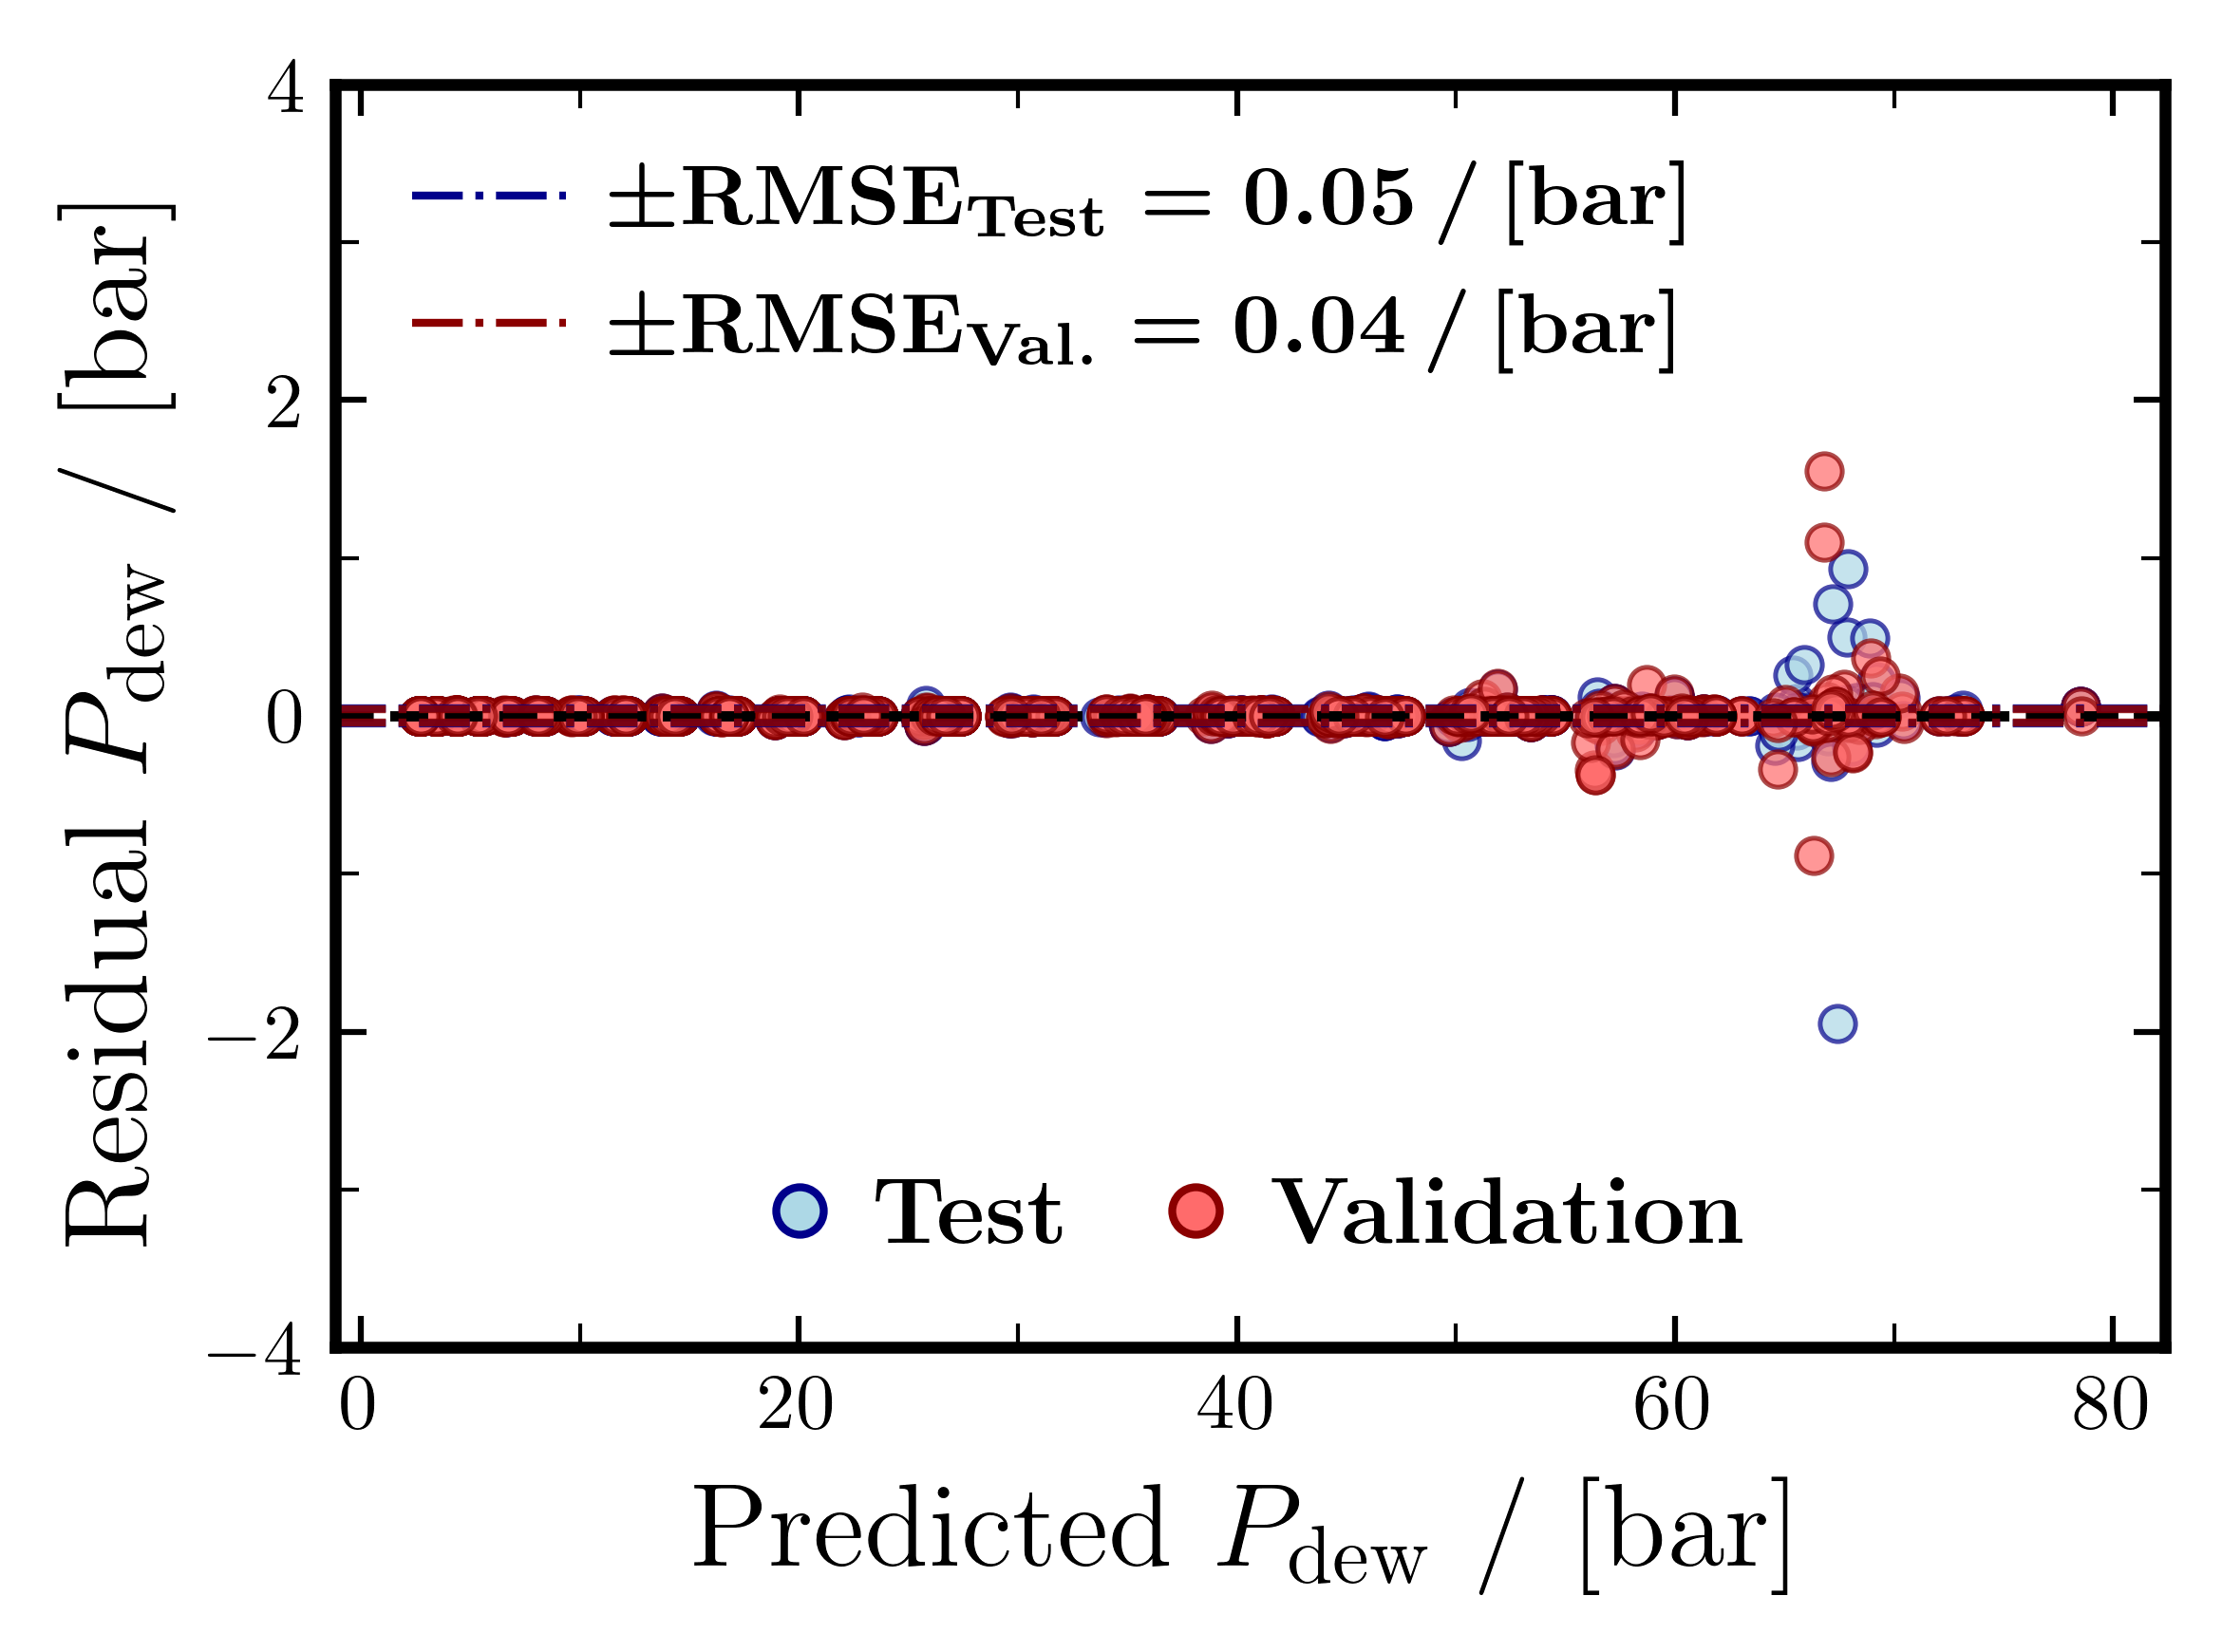

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $P_{\\mathrm{dew}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Residual}$ $P_{\\mathrm{dew}}$ / $[\\mathrm{bar}]$'>)

In [16]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(
    save_path="RF_P_dew_residual_vs_predicted",
    folder=OUTPUT_FOLDER,
    y_range=[-4, 4],
    legend_fontsize=12,         # legend text size
    legend_bold=True,           # bold legend labels (math incl. under usetex)
    legend_loc="lower center",  # Test/Validation marker-legend location
    legend_handletextpad=0.3,   # gap between marker and text
    legend_handlelength=1.0,    # marker-box width (smaller -> marker closer to text)
    label_fontsize=15,          # x/y axis label size
    labelpad=4,                # gap between axis and its label (points)
    decimals=2,                 # decimal places for RMSE in legend
)

In [17]:
post.print_summary()

# Collect all metrics
metrics["oob_score"]       = float(rf_model.oob_score_)
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["model"]           = "RandomForest"
metrics["n_estimators"]    = rf_model.n_estimators
metrics["max_depth"]       = rf_model.max_depth
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_DEW
Samples:        2904
R² Score:       0.999993
RMSE:           0.047525
MAE:            0.004663
Mean Residual:  0.000172
Std Residual:   0.047525

FEATURE IMPORTANCES:
------------------------------------------------------------
  temperature               |  99.84% | █████████████████████████████████████████████████
  z_carbon dioxide          |   0.08% | 
  pressure                  |   0.03% | 
  z_hydrogen sulfide        |   0.03% | 
  z_hydrogen                |   0.01% | 
  z_methane                 |   0.00% | 
  z_argon                   |   0.00% | 
  z_oxygen                  |   0.00% | 
  z_carbon monoxide         |   0.00% | 
  z_nitrogen                |   0.00% | 

Metrics saved to: RF_Pdew_OUTPUTS/RF_P_dew_metrics.json


In [18]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 4.06 minutes
